This code is a little messy, but we must extract data from .tar files and organize it better. Once moved we can move to more processing. 

In [1]:
import pandas as pd
import numpy as np
import math
import datetime as dt
from matplotlib import pyplot as plt
import os
import shutil
import glob

import lidar_functions as lf
from scipy.interpolate import griddata
from scipy.signal import argrelextrema, find_peaks


In [2]:
extract = False # ONLY NEED TO RUN THIS ONCE, SET TO FALSE AFTER DATA IS IN THE CORRECT DIR. 
if extract:
    os.makedirs('./data/raw_lidar/extracted_data', exist_ok=True) 
    dir = './data/raw_lidar'
    os.listdir(dir)
    extracted_lidar_dir = './data/raw_lidar/extracted_data'
    os.makedirs('./data/raw_lidar/extracted_data', exist_ok=True) 
    
    for file in os.listdir(dir):
        # we have tar files. we can extract these with a lf function 
        if file.endswith('.tar'):
            full_path_file = os.path.join(dir, file)
            print(f'extracting {full_path_file} to {extracted_lidar_dir}...')
            lf.extract_data(full_path_file, extracted_lidar_dir)

    # Tar files are files of files. This creates a messy directory. This will move it from that directory to make it a little easier to navigate
    # Define the source and destination paths
    temp_dir = './data/raw_lidar/extracted_data/Users/HISCOX/OneDrive - University of South Carolina/Research/SAVANT/SAVANT Data/Level 1 - Grouped/USC Aerosol Lidar/ASCII'
    source_directory = './data/raw_lidar/extracted_data/ASCII/'
    destination_directory = extracted_lidar_dir
    
    try:
        # Move the directory
        for folder in os.listdir(source_directory):
            print(folder)
            shutil.move(os.path.join(source_directory,folder), destination_directory)
            print(f"Directory '{source_directory}' moved successfully to '{destination_directory}'")
    except FileNotFoundError:
        print(f"Error: Source directory '{source_directory}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")

Now I have each night of data in a folder. Every file is one line of sight data in the extracted_data dir

In [3]:
oct27 = './data/raw_lidar/extracted_data/11022018/'
oct27_data = os.listdir(oct27)

In [4]:
f = os.path.join(oct27, oct27_data[50])
meta_data = []
shot_data = []
with open(f, 'r') as file:
    content = file.readlines()

    # The first seven lines are meta data
    meta = content[0:7]
    
    header1 = meta[0]
    header2 = meta[1]
    header3 = meta[2]
    header4 = meta[3]
    header5 = meta[4]
    header6 = meta[5]
    header7 = meta[6]
    
    header2 = header2.split(' ')
    campaign = header2[0]
    startDate = f'{header2[3]} {header2[4]}'
    endDate = f'{header2[5]} {header2[6]}'
    elevation = float(header2[7])
    longitude = float(header2[8])
    latitude = float(header2[9])
    zenith = float(header2[10])*-1
    azimuth = float(header2[11])
    temp_ground = float(header2[12])
    pressure = float(header2[13])
    bin_width = float(header5.split()[6])
    data = content[7:]

# Create a dataframe for the meta data
meta_data.append([f, startDate, endDate, elevation, longitude, latitude, zenith, azimuth, temp_ground, pressure])

# Create DF
meta_df = pd.DataFrame(meta_data, columns=['file', 'start', 'end', 'elevation', 'longitude', 'latitude', 'zenith', 'azimuth', 'temp_ground', 'pressure'])

# Convert appropriate columns to numeric
numeric_cols = ['elevation', 'longitude', 'latitude', 'zenith', 'azimuth', 'temp_ground', 'pressure']
meta_df[numeric_cols] = meta_df[numeric_cols].apply(pd.to_numeric, errors='coerce')  # Convert and set non-numeric values to NaN

# Convert date columns to datetime
meta_df['start'] = pd.to_datetime(meta_df['start'], errors='coerce', dayfirst=True)
meta_df['end'] = pd.to_datetime(meta_df['end'], errors='coerce', dayfirst=True)
meta_df



,file,start,end,elevation,longitude,latitude,zenith,azimuth,temp_ground,pressure
0,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 22:05:49,2018-11-02 22:05:49,214.0,40.2,88.4,3.2,3.2,6.0,1013.0


In [5]:
my_data = []
for row in data:
    d = row.strip().split('\t')
    my_data.append(d)
df = pd.DataFrame(my_data, columns=['analog', 'photon'])
df = df.apply(pd.to_numeric)
df['angle'] = azimuth
# df['scan_id'] = scan
df['start'] = startDate
df['start'] = pd.to_datetime(df['start'])
df['end'] = endDate
df['end'] = pd.to_datetime(df['end'])
df['distance'] = (df.index +1) * bin_width
df['x'] = df['distance'] * np.cos(np.radians(azimuth))
df['z'] = df['distance'] * np.sin(np.radians(azimuth))
df

,analog,photon,angle,start,end,distance,x,z
0,3.7842,124.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,7.5,7.488306,0.418661
1,3.8086,140.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,15.0,14.976611,0.837323
2,3.8086,136.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,22.5,22.464917,1.255984
3,3.8086,164.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,30.0,29.953223,1.674645
4,3.8330,164.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,37.5,37.441529,2.093306
...,...,...,...,...,...,...,...,...
16335,3.7354,0.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,122520.0,122328.962428,6839.250792
16336,3.8330,0.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,122527.5,122336.450733,6839.669453
16337,3.7842,0.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,122535.0,122343.939039,6840.088114
16338,3.8086,0.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,122542.5,122351.427345,6840.506776


In [6]:
df.describe()

,analog,photon,angle,start,end,distance,x,z
count,16340.000000,16340.000000,1.634000e+04,16340,16340,16340.00000,16340.000000,16340.000000
mean,3.891538,0.948103,3.200000e+00,2018-02-11 22:05:48.999999744,2018-02-11 22:05:48.999999744,61278.75000,61183.201978,3420.672049
min,3.662100,0.000000,3.200000e+00,2018-02-11 22:05:49,2018-02-11 22:05:49,7.50000,7.488306,0.418661
25%,3.784200,0.000000,3.200000e+00,2018-02-11 22:05:49,2018-02-11 22:05:49,30643.12500,30595.345142,1710.545355
50%,3.808600,0.000000,3.200000e+00,2018-02-11 22:05:49,2018-02-11 22:05:49,61278.75000,61183.201978,3420.672049
75%,3.833000,0.000000,3.200000e+00,2018-02-11 22:05:49,2018-02-11 22:05:49,91914.37500,91771.058814,5130.798743
max,66.308600,192.000000,3.200000e+00,2018-02-11 22:05:49,2018-02-11 22:05:49,122550.00000,122358.915651,6840.925437
std,1.851355,10.542770,8.882056e-16,NaN,NaN,35378.22026,35323.057272,1974.865499


/tmp/ipykernel_1152263/881522865.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['analog_bgc'] = np.where(df['analog'] >= EndSig_A - 3 * EndSig_A_std, df['analog'] - EndSig_A, 0)
/tmp/ipykernel_1152263/881522865.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['photon_bgc'] = np.where(df['photon'] >= EndSig_P - 3 * EndSig_P_std, df['photon'] - EndSig_P, 0)


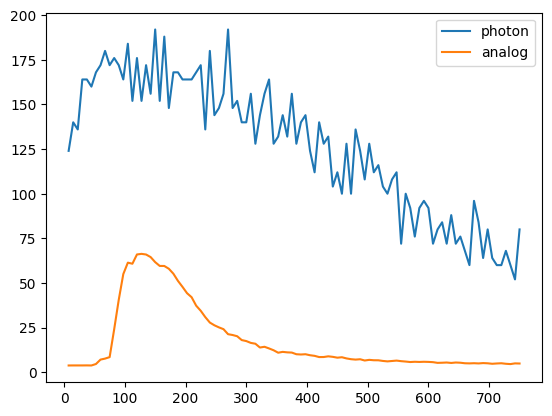

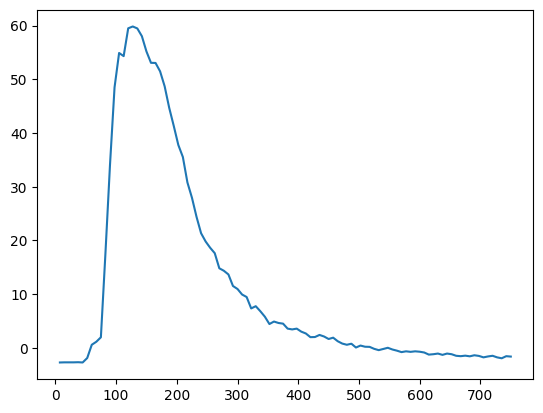

In [7]:
df = df[df['distance']<=750]

bg_length = min(1000, int(len(df)/2))
EndSig_A, EndSig_P = df['analog'][-bg_length:].mean(), df['photon'][-bg_length:].mean()
EndSig_A_std, EndSig_P_std = df['analog'][-bg_length:].std(), df['photon'][-bg_length:].std()

df['analog_bgc'] = np.where(df['analog'] >= EndSig_A - 3 * EndSig_A_std, df['analog'] - EndSig_A, 0)
df['photon_bgc'] = np.where(df['photon'] >= EndSig_P - 3 * EndSig_P_std, df['photon'] - EndSig_P, 0)

Ranges=np.arange(7.5,df['distance'].max()+1,7.5)

xrange = np.arange(7.5,df['distance'].max()+1,7.5)
range_corr = np.ones(len(xrange)) * xrange**2

plt.plot(df['distance'], df['photon'], label='photon')
plt.plot(df['distance'], df['analog'], label='analog')
# plt.plot(xrange, range_corr)
plt.legend()
plt.show()

plt.plot(df['distance'], df['analog_bgc'])
plt.show()

In [8]:
df['distance'].max()

np.float64(750.0)

In [9]:
#range square
Ranges=np.arange(7.5,df['distance'].max()+1,7.5)
Ranges
# if R2 == 'True':
#     data['analog']=data['analog']*Ranges**2
#     data['photon']=data['photon']*Ranges**2

df['photon_cor']=df['photon']*Ranges**2
df['analog_cor']=df['analog']*Ranges**2
df['analog_bg_range_cor']=df['analog_bgc']*Ranges**2
df

/tmp/ipykernel_1152263/1560998683.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['photon_cor']=df['photon']*Ranges**2
/tmp/ipykernel_1152263/1560998683.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['analog_cor']=df['analog']*Ranges**2
/tmp/ipykernel_1152263/1560998683.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas

,analog,photon,angle,start,end,distance,x,z,analog_bgc,photon_bgc,photon_cor,analog_cor,analog_bg_range_cor
0,3.7842,124.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,7.5,7.488306,0.418661,-2.698222,28.0,6975.0,2.128612e+02,-1.517750e+02
1,3.8086,140.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,15.0,14.976611,0.837323,-2.673822,44.0,31500.0,8.569350e+02,-6.016099e+02
2,3.8086,136.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,22.5,22.464917,1.255984,-2.673822,40.0,68850.0,1.928104e+03,-1.353622e+03
3,3.8086,164.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,30.0,29.953223,1.674645,-2.673822,68.0,147600.0,3.427740e+03,-2.406440e+03
4,3.8330,164.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,37.5,37.441529,2.093306,-2.649422,68.0,230625.0,5.390156e+03,-3.725750e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5.0293,60.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,720.0,718.877350,40.191484,-1.453122,-36.0,31104000.0,2.607189e+06,-7.532984e+05
96,4.7363,68.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,727.5,726.365656,40.610145,-1.746122,-28.0,35989425.0,2.506716e+06,-9.241460e+05
97,4.5654,60.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,735.0,733.853962,41.028806,-1.917022,-36.0,32413500.0,2.466343e+06,-1.035623e+06
98,4.9561,52.0,3.2,2018-02-11 22:05:49,2018-02-11 22:05:49,742.5,741.342267,41.447467,-1.526322,-44.0,28667925.0,2.732329e+06,-8.414709e+05


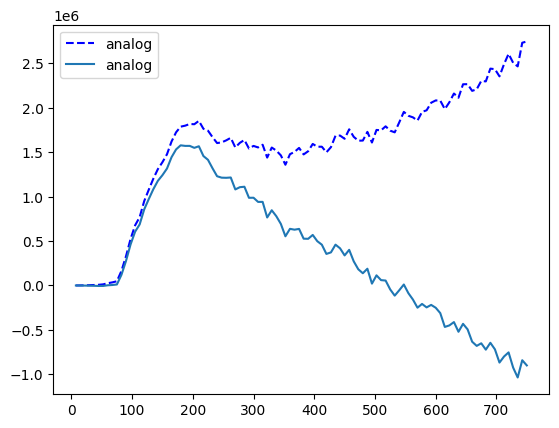

In [10]:
# plt.plot(df['distance'], df['photon'], label='photon', color='orange')
# plt.plot(df['distance'], df['analog'], label='analog', color='blue')
# plt.plot(df['distance'], df['photon_cor'], label='photon', color='orange', linestyle='--')
plt.plot(df['distance'], df['analog_cor'], label='analog', color='blue', linestyle='--')
plt.plot(df['distance'], df['analog_bg_range_cor'], label='analog')
plt.legend()
plt.show()

elevation angles -40.2


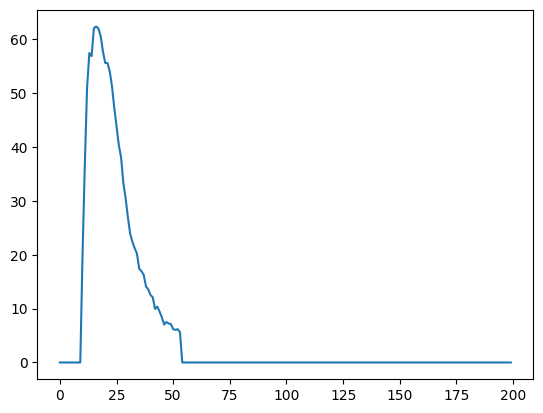

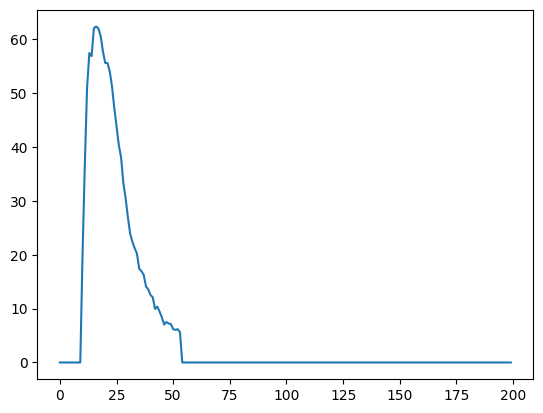

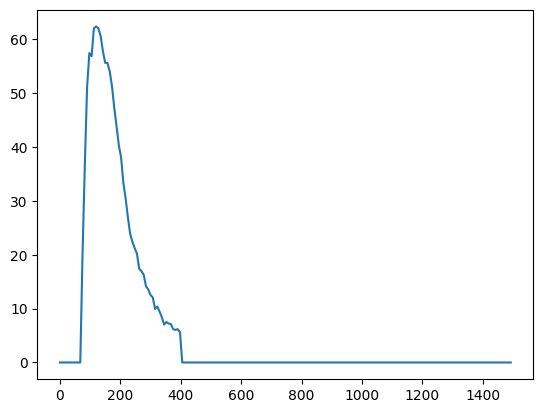

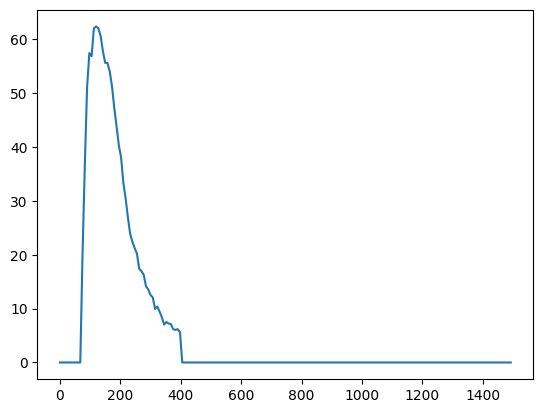

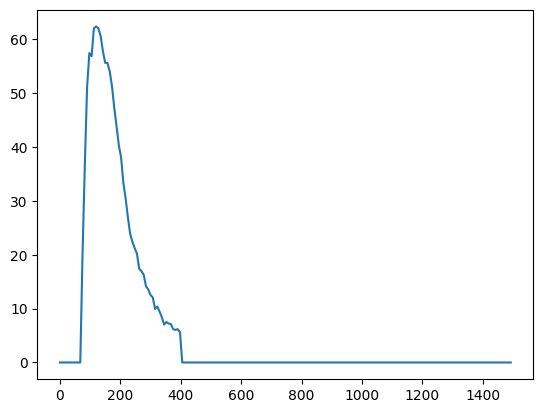

In [11]:
fil = f
bg_length=0
norm=True
R2=True
log_corr=True
smooth=0.0
RefX = 0
RefY = 0
RefZ = 0
South=True


with open(f, 'r') as F:
    Lz = F.readlines()
    Lz[1].split(' ')
    #extract information
    Location = Lz[1].split(' ')[0]
    Date = Lz[1].split(' ')[1]
    Time = Lz[1].split(' ')[2]
    Zenith = Lz[1].split(' ')[8]
    if Lz[2].split(' ')[3] == Lz[2].split(' ')[4]:
        Zenith = Lz[2].split(' ')[3]
    Azimuth = Lz[1].split(' ')[9]
    if Lz[2].split(' ')[0] == Lz[2].split(' ')[1]:
        Azimuth = Lz[2].split(' ')[0]
    Zenith = -float(Zenith)
    if float(Azimuth) < 0.0:
        Azimuth=abs(float(Azimuth))+ az_offset
        South=True
    else:
        Azimuth = float(Azimuth)+90
    #print Azimuth
    F.close()
    data=np.genfromtxt(fil, dtype=float, skip_header=7,names=('analog', 'photon'), autostrip=True)
    print ('elevation angles', Zenith)
    # average noise and stdev are calculated from last 1000 bins, or users choice
    
    num_bins=len(data['analog'])
    if bg_length == 0:
        bg_length = num_bins
    EndSig_A=np.mean(data['analog'][num_bins-bg_length:num_bins])
    EndSig_P=np.mean(data['photon'][num_bins-bg_length:num_bins])
    EndSig_A_std=np.std(data['analog'][num_bins-bg_length:num_bins])
    EndSig_P_std=np.std(data['photon'][num_bins-bg_length:num_bins])
    
    #subtract background level
    # values below(bg + 3 * std) become zero
    for sig in range(0,num_bins):
        if data['analog'][sig] >= EndSig_A+3*EndSig_A_std:
            data['analog'][sig]=data['analog'][sig]-EndSig_A
        else:
            data['analog'][sig] = 0
        if data['photon'][sig] >= EndSig_P+3*EndSig_P_std:
            data['photon'][sig]=data['photon'][sig]-EndSig_P
        else:
            data['photon'][sig] = 0
    plt.plot(data['analog'][0:200])
    plt.show()
    
    #normalize to peak
    if norm == 'True':
        peak=max(data['analog'][0:30])
        print (peak)
        print (data['analog'])
        data['analog'][:]=data['analog'][:]/peak
        print (data['analog'])
    #find background level
    plt.plot(data['analog'][0:200])
    plt.show()
    
    #range square
    Ranges=np.arange(0,num_bins*7.5,7.5)
    if R2 == 'True':
        data['analog']=data['analog']*Ranges**2
        data['photon']=data['photon']*Ranges**2
    plt.plot(Ranges[0:200], data['analog'][0:200])
    plt.show()
    
    # smooth
    if smooth > 0.0:
        temp=sm.nonparametric.lowess(data['analog'],Ranges, frac=smooth)
        data['analog']=[row[1] for row in temp]
    plt.plot(Ranges[0:200], data['analog'][0:200])
    plt.show()
    # print data['analog']
    
    # log correct
    if log_corr == 'True':
        data['analog']=np.log(data['analog'])
        data['photon']=np.log(data['photon'])
    
    plt.plot(Ranges[0:200], data['analog'][0:200])
    plt.show()
    
    # compute points
    Z=Ranges*np.sin(Zenith*np.pi/180)+RefZ
    GD = (Ranges**2-Z**2)**.5
    X = GD*np.cos(Azimuth*np.pi/180)+RefX
    if South == True:
        Y = -GD*np.sin(Azimuth*np.pi/180)+RefY
    else:
        Y=GD*np.sin(Azimuth*np.pi/180)+RefY

In [12]:
data

array([(0., 123.05189718), (0., 139.05189718), (0., 135.05189718), ...,
       (0.,   0.        ), (0.,   0.        ), (0.,   0.        )],
      dtype=[('analog', '<f8'), ('photon', '<f8')])

In [13]:
df = pd.DataFrame(data)


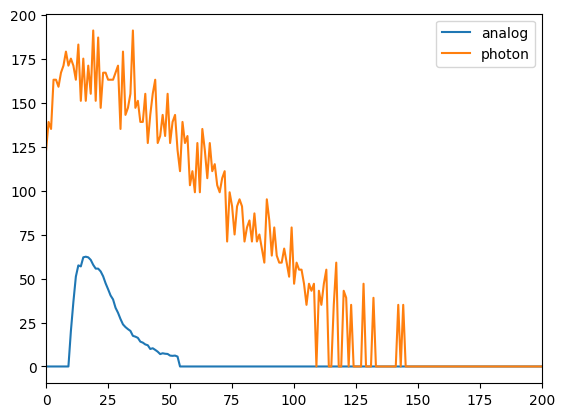

In [14]:
plt.plot(df['analog'], label='analog')
plt.plot(df['photon'], label='photon')
plt.legend()
plt.xlim(0,200)
plt.show()

In [15]:
# read_metadata(oct27, oct27_data[50])
directory= oct27
file_path = None #oct27_data[50]
if file_path == None:
    files_to_read = [txt for txt in os.listdir(directory) if txt.endswith('.txt')]
if file_path != None:
    files_to_read = [file_path]
len(files_to_read) # 10006

10005

In [16]:
# Create a function to read all meta data from a directory...
def read_metadata(directory, file_path = None):
    if file_path == None:
        files_to_read = [txt for txt in os.listdir(directory) if txt.endswith('.txt')]
    if file_path != None:
        files_to_read = [file_path]

    meta_df = pd.DataFrame(columns=['file', 'start', 'end', 'elevation', 'longitude', 'latitude', 'zenith', 'azimuth', 'temp_ground', 'pressure'])
    
    # Convert appropriate columns to numeric
    numeric_cols = ['elevation', 'longitude', 'latitude', 'zenith', 'azimuth', 'temp_ground', 'pressure']
    # meta_df[numeric_cols] = meta_df[numeric_cols].apply(pd.to_numeric, errors='coerce')  # Convert and set non-numeric values to NaN
    
    for txt_file in files_to_read:
        f = os.path.join(directory, txt_file)
        meta_data = []
        shot_data = []
        with open(f, 'r') as file:
            content = file.readlines()
        
            # The first seven lines are meta data
            meta = content[0:7]
            
            header1 = meta[0]
            header2 = meta[1]
            header3 = meta[2]
            header4 = meta[3]
            header5 = meta[4]
            header6 = meta[5]
            header7 = meta[6]
            
            header2 = header2.split(' ')
            campaign = header2[0]
            startDate = f'{header2[3]} {header2[4]}'
            endDate = f'{header2[5]} {header2[6]}'
            elevation = float(header2[7])
            longitude = float(header2[8])
            latitude = float(header2[9])
            zenith = float(header2[10])*-1
            azimuth = float(header2[11])
            temp_ground = float(header2[12])
            pressure = float(header2[13])
            bin_width = float(header5.split()[6])
            data = content[7:]
        
        # Create a dataframe for the meta data
        meta_data.append([f, startDate, endDate, elevation, longitude, latitude, zenith, azimuth, temp_ground, pressure])
        
        # Create DF
        temp_meta_df = pd.DataFrame(meta_data, columns=['file', 'start', 'end', 'elevation', 'longitude', 'latitude', 'zenith', 'azimuth', 'temp_ground', 'pressure'])
        
        # Convert appropriate columns to numeric
        # numeric_cols = ['elevation', 'longitude', 'latitude', 'zenith', 'azimuth', 'temp_ground', 'pressure']
        # temp_meta_df[numeric_cols] = temp_meta_df[numeric_cols].apply(pd.to_numeric, errors='coerce')  # Convert and set non-numeric values to NaN
        
        # Convert date columns to datetime
        temp_meta_df['start'] = pd.to_datetime(temp_meta_df['start'], errors='coerce', dayfirst=True)
        temp_meta_df['end'] = pd.to_datetime(temp_meta_df['end'], errors='coerce', dayfirst=True)
        meta_df = pd.concat([meta_df, temp_meta_df], ignore_index=True)
    meta_df = meta_df.sort_values('start')
    return meta_df

test_meta = read_metadata(oct27)
test_meta

/tmp/ipykernel_1152263/4112746237.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  meta_df = pd.concat([meta_df, temp_meta_df], ignore_index=True)


,file,start,end,elevation,longitude,latitude,zenith,azimuth,temp_ground,pressure
6728,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 11:13:08,2018-11-02 11:13:10,214.0,40.2,88.4,-0.0,-10.0,6.0,1013.0
9765,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 11:13:14,2018-11-02 11:13:16,214.0,40.2,88.4,-0.0,-9.0,6.0,1013.0
6071,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 11:13:49,2018-11-02 11:13:51,214.0,40.2,88.4,-0.0,-10.0,6.0,1013.0
4883,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 11:13:55,2018-11-02 11:13:57,214.0,40.2,88.4,-0.0,-9.0,6.0,1013.0
4080,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 11:14:02,2018-11-02 11:14:03,214.0,40.2,88.4,-0.0,-8.0,6.0,1013.0
...,...,...,...,...,...,...,...,...,...,...
2306,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 23:48:02,2018-11-02 23:48:02,214.0,40.2,88.4,2.1,3.2,6.0,1013.0
7768,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 23:48:06,2018-11-02 23:48:06,214.0,40.2,88.4,2.2,3.2,6.0,1013.0
244,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 23:48:10,2018-11-02 23:48:10,214.0,40.2,88.4,2.3,3.2,6.0,1013.0
7754,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 23:48:14,2018-11-02 23:48:14,214.0,40.2,88.4,2.4,3.2,6.0,1013.0


In [17]:
# test_meta = test_meta.sort_values('start')
test_meta

,file,start,end,elevation,longitude,latitude,zenith,azimuth,temp_ground,pressure
6728,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 11:13:08,2018-11-02 11:13:10,214.0,40.2,88.4,-0.0,-10.0,6.0,1013.0
9765,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 11:13:14,2018-11-02 11:13:16,214.0,40.2,88.4,-0.0,-9.0,6.0,1013.0
6071,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 11:13:49,2018-11-02 11:13:51,214.0,40.2,88.4,-0.0,-10.0,6.0,1013.0
4883,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 11:13:55,2018-11-02 11:13:57,214.0,40.2,88.4,-0.0,-9.0,6.0,1013.0
4080,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 11:14:02,2018-11-02 11:14:03,214.0,40.2,88.4,-0.0,-8.0,6.0,1013.0
...,...,...,...,...,...,...,...,...,...,...
2306,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 23:48:02,2018-11-02 23:48:02,214.0,40.2,88.4,2.1,3.2,6.0,1013.0
7768,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 23:48:06,2018-11-02 23:48:06,214.0,40.2,88.4,2.2,3.2,6.0,1013.0
244,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 23:48:10,2018-11-02 23:48:10,214.0,40.2,88.4,2.3,3.2,6.0,1013.0
7754,./data/raw_lidar/extracted_data/11022018/S18B0...,2018-11-02 23:48:14,2018-11-02 23:48:14,214.0,40.2,88.4,2.4,3.2,6.0,1013.0


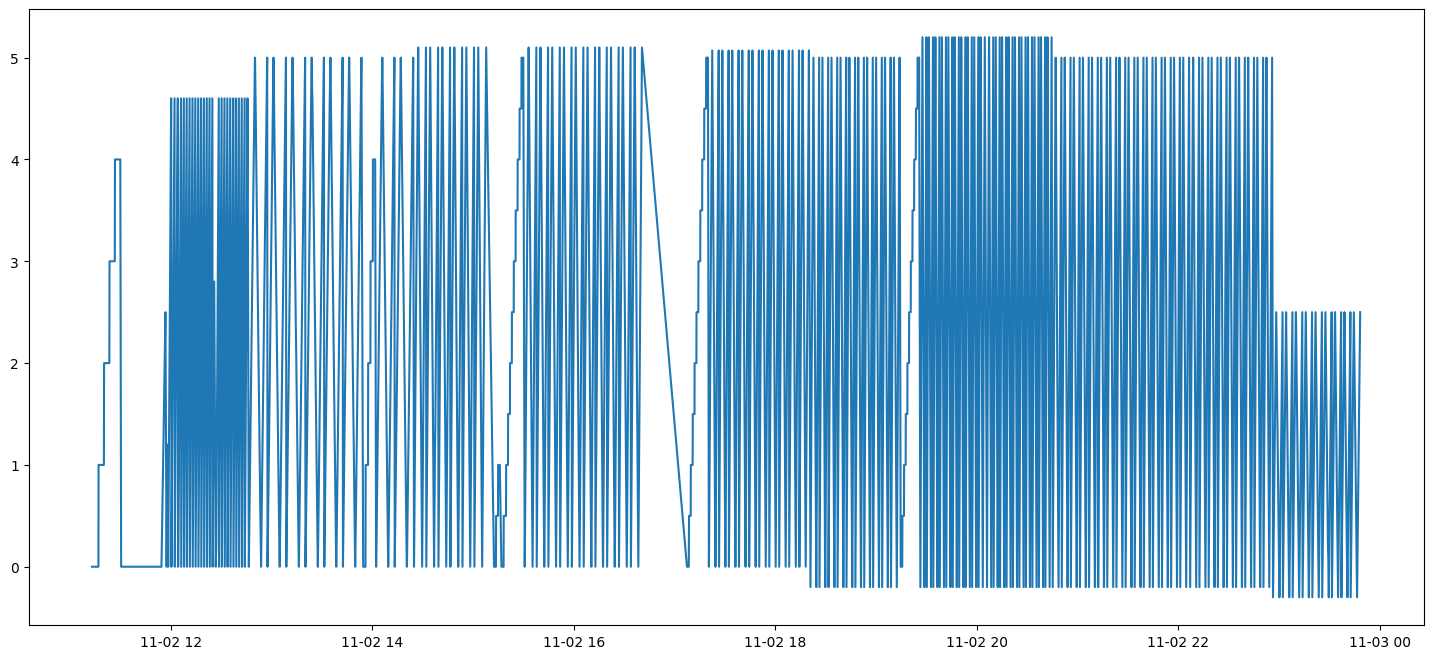

In [18]:

plt.figure(figsize=(18,8))
plt.plot(test_meta['start'], test_meta['zenith'])
# t1 = pd.to_datetime('2018-11-02 14:20')
# t2 = pd.to_datetime('2018-11-02 15:00')
# plt.xlim(t1, t2)
plt.show()

In [19]:
test_meta.describe()

,start,end,elevation,longitude,latitude,zenith,azimuth,temp_ground,pressure
count,10005,10005,10005.0,10005.0,1.000500e+04,10005.000000,10005.000000,10005.0,10005.0
mean,2018-11-02 17:55:35.273862912,2018-11-02 17:55:35.400499712,214.0,40.2,8.840000e+01,2.331864,2.620540,6.0,1013.0
min,2018-11-02 11:13:08,2018-11-02 11:13:10,214.0,40.2,8.840000e+01,-0.300000,-10.000000,6.0,1013.0
25%,2018-11-02 14:48:18,2018-11-02 14:48:18,214.0,40.2,8.840000e+01,1.000000,2.800000,6.0,1013.0
50%,2018-11-02 18:09:34,2018-11-02 18:09:34,214.0,40.2,8.840000e+01,2.200000,3.000000,6.0,1013.0
75%,2018-11-02 21:00:06,2018-11-02 21:00:06,214.0,40.2,8.840000e+01,3.600000,3.200000,6.0,1013.0
max,2018-11-02 23:48:18,2018-11-02 23:48:18,214.0,40.2,8.840000e+01,5.200000,20.000000,6.0,1013.0
std,NaN,NaN,0.0,0.0,1.421156e-14,1.537983,1.821264,0.0,0.0


In [20]:
lidar_file = './data/raw_lidar/extracted_data/11072018/'
d_1107_meta = read_metadata(lidar_file)
d_1107_meta.describe()

/tmp/ipykernel_1152263/4112746237.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  meta_df = pd.concat([meta_df, temp_meta_df], ignore_index=True)


,start,end,elevation,longitude,latitude,zenith,azimuth,temp_ground,pressure
count,203,203,203.0,2.030000e+02,2.030000e+02,203.000000,203.000000,203.0,203.0
mean,2018-11-08 02:40:59.812807936,2018-11-08 02:40:59.857142784,214.0,4.020000e+01,8.840000e+01,0.002463,0.098030,6.0,1013.0
min,2018-11-08 02:31:24,2018-11-08 02:31:24,214.0,4.020000e+01,8.840000e+01,-0.000000,-10.000000,6.0,1013.0
25%,2018-11-08 02:36:12,2018-11-08 02:36:12,214.0,4.020000e+01,8.840000e+01,-0.000000,-4.950000,6.0,1013.0
50%,2018-11-08 02:41:00,2018-11-08 02:41:00,214.0,4.020000e+01,8.840000e+01,0.000000,0.100000,6.0,1013.0
75%,2018-11-08 02:45:48,2018-11-08 02:45:48,214.0,4.020000e+01,8.840000e+01,-0.000000,5.150000,6.0,1013.0
max,2018-11-08 02:50:36,2018-11-08 02:50:36,214.0,4.020000e+01,8.840000e+01,0.250000,10.000000,6.0,1013.0
std,NaN,NaN,0.0,7.122993e-15,1.424599e-14,0.024753,5.871166,0.0,0.0


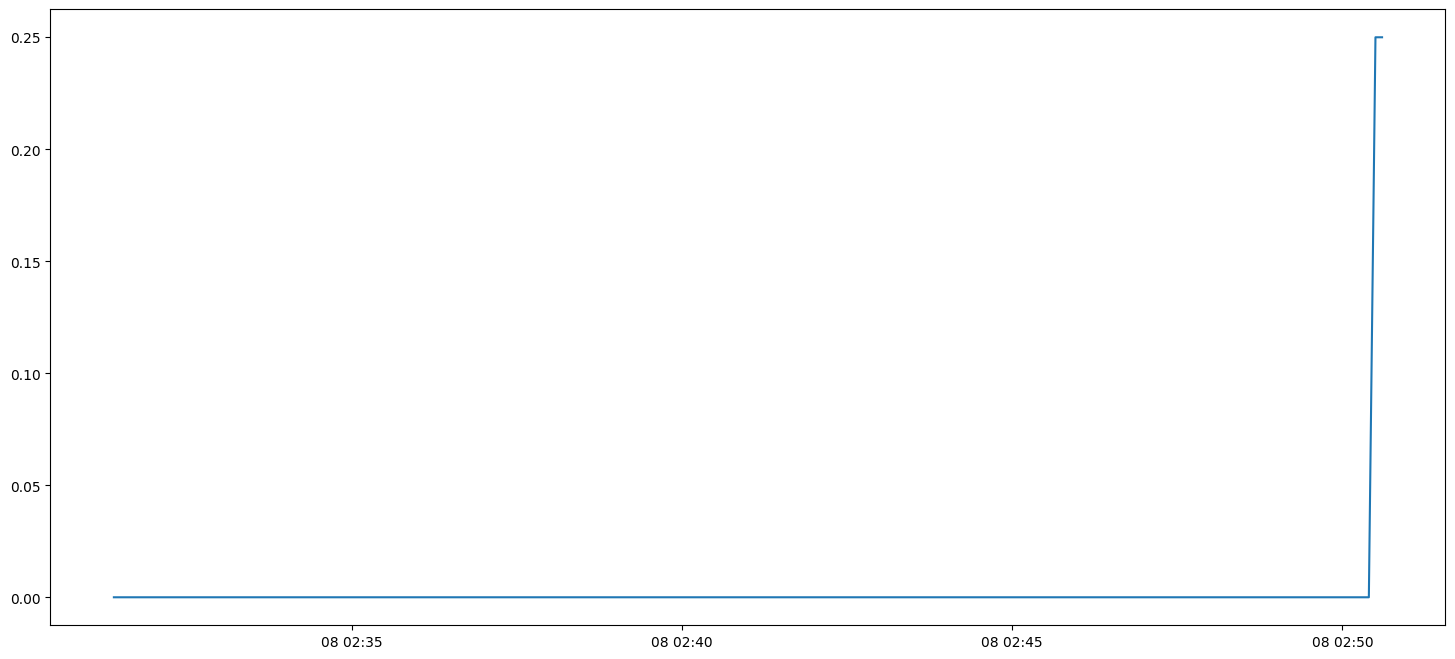

In [21]:
plt.figure(figsize=(18,8))
plt.plot(d_1107_meta['start'], d_1107_meta['zenith'])
# t1 = pd.to_datetime('2018-11-02 14:20')
# t2 = pd.to_datetime('2018-11-02 15:00')
# plt.xlim(t1, t2)
plt.show()

In [22]:
def file_to_data(txt_file, max_distance=500, bin_width=7.5, origin_X=0, origin_Y=0, origin_Z=2, origin_azimuth=0, origin_zenith=0):
    '''
    Reads a LiDAR text file, extracts measurement data, processes background noise correction, and computes 
    spatial coordinates for each data point.

    Parameters:
    txt_file (str): Path to the LiDAR text file.
    distance (float, optional): Maximum measurement distance. Default is 450.
    bin_width (float, optional): Width of each measurement bin. Default is 7.5.

    Returns:
    pandas.DataFrame: A DataFrame containing the processed LiDAR data with background noise correction and 
    spatial coordinates (x, z, distance).
    '''
    with open(txt_file, 'r') as file:
        content = file.readlines()
    
    meta = content[:7]
    shot_data = meta[1]
    Location, StartDate, StartTime, EndDate, EndTime, Elevation, Longitude, Latitude, Zenith, Azimuth, Temp, Pressure = shot_data.split()
    Zenith = -float(Zenith)
    last_row = int(math.ceil(max_distance/bin_width))
    data = [row.strip().split('\t') for row in content[7:(7+last_row)]]
    
    data = pd.DataFrame(data, columns=['analog', 'photon']).apply(pd.to_numeric)

    # Add data from meta data
    data['start'] = pd.to_datetime(f"{StartDate} {StartTime}", format='%d/%m/%Y %H:%M:%S')
    data['end'] = pd.to_datetime(f"{EndDate} {EndTime}", format='%d/%m/%Y %H:%M:%S')
    data['zenith'] = Zenith

    # # for testing, plot analog signal
    # plt.plot(data['analog'])
    # plt.show()
    
    # First perform Background correction. We need to remove the noise.
    bg_length = min(1000, int(len(data)/2))
    EndSig_A, EndSig_P = data['analog'][-bg_length:].mean(), data['photon'][-bg_length:].mean()
    EndSig_A_std, EndSig_P_std = data['analog'][-bg_length:].std(), data['photon'][-bg_length:].std()
    
    data['analog_bgc'] = np.where(data['analog'] >= EndSig_A + EndSig_A_std, data['analog'] - EndSig_A, 0)  # + 3 
    data['photon_bgc'] = np.where(data['photon'] >= EndSig_P + EndSig_P_std, data['photon'] - EndSig_P, 0)   # + 3 

    # Add distance information
    step_size = bin_width
    data['distance'] = (data.index+1) * step_size 
    data['x'] = data['distance'] * np.cos(np.radians(Zenith))
    data['z'] = origin_Z + data['distance'] * np.sin(np.radians(Zenith))
    
    # Range correction. Inverse-square law of light
    Ranges=data['distance'].values
    data['analog_rcs']=data['analog_bgc'] *Ranges**2
    data['photon_rcs']=data['photon_bgc'] *Ranges**2
    
    # Normalize data
    peak=max(data['analog_rcs'])
    data['analog_rcs']=data['analog_rcs']/peak
    
    return data


In [23]:
test_lidar_scan = file_to_data('./data/raw_lidar/extracted_data/11022018/S18B0211.131016.txt')
test_lidar_scan.head()



,analog,photon,start,end,zenith,analog_bgc,photon_bgc,distance,x,z,analog_rcs,photon_rcs
0,4.7247,40.5,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,0.0,0.000000,7.5,7.5,2.0,0.0,0.000000
1,4.7211,68.5,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,0.0,0.000000,15.0,15.0,2.0,0.0,0.000000
2,4.7180,114.5,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,0.0,0.000000,22.5,22.5,2.0,0.0,0.000000
3,4.7235,138.0,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,0.0,21.378788,30.0,30.0,2.0,0.0,19240.909091
4,4.7229,135.0,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,0.0,18.378788,37.5,37.5,2.0,0.0,25845.170455


In [24]:
test_lidar_scan['analog'].std()#[-bg_length:].std()

np.float64(14.048193048792985)

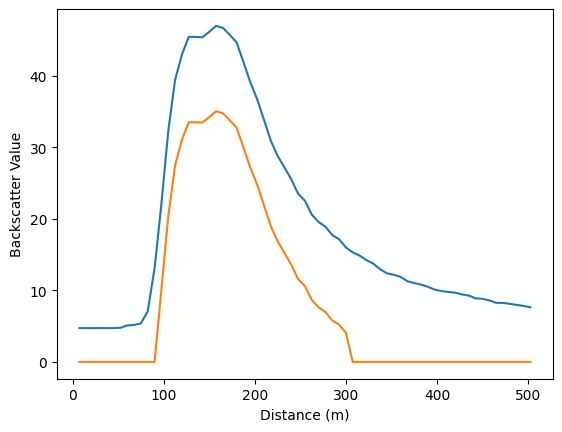

In [25]:
plt.plot(test_lidar_scan['distance'], test_lidar_scan['analog'],  label='Raw Signal')
plt.plot(test_lidar_scan['distance'], test_lidar_scan['analog_bgc'], label='Background Corrected')
# plt.plot(test_lidar_scan['distance'], test_lidar_scan['analog_rcs'], label='Range Corrected')
plt.xlabel('Distance (m)')
plt.ylabel('Backscatter Value')
plt.show()

In [26]:
test_lidar_scan.describe()

,analog,photon,start,end,zenith,analog_bgc,photon_bgc,distance,x,z,analog_rcs,photon_rcs
count,67.000000,67.000000,67,67,67.0,67.000000,67.000000,67.000000,67.000000,67.0,67.000000,6.700000e+01
mean,19.031707,124.925373,2018-11-02 11:13:08.000000256,2018-11-02 11:13:10,0.0,8.789162,11.365898,255.000000,255.000000,2.0,0.273132,3.399526e+05
min,4.718000,40.500000,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,0.000000,0.000000,7.500000,7.500000,2.0,0.000000,0.000000e+00
25%,8.421950,116.250000,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,0.000000,0.000000,131.250000,131.250000,2.0,0.000000,0.000000e+00
50%,12.949800,128.500000,2018-11-02 11:13:08,2018-11-02 11:13:10,0.0,0.000000,11.878788,255.000000,255.000000,2.0,0.000000,6.305966e+04
75%,27.975800,138.250000,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,16.054524,21.628788,378.750000,378.750000,2.0,0.569324,6.656928e+05
max,46.931200,145.500000,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,35.009924,28.878788,502.500000,502.500000,2.0,1.000000,1.554609e+06
std,14.048193,18.396569,NaN,NaN,0.0,12.629823,10.897625,146.137777,146.137777,0.0,0.362176,4.409415e+05


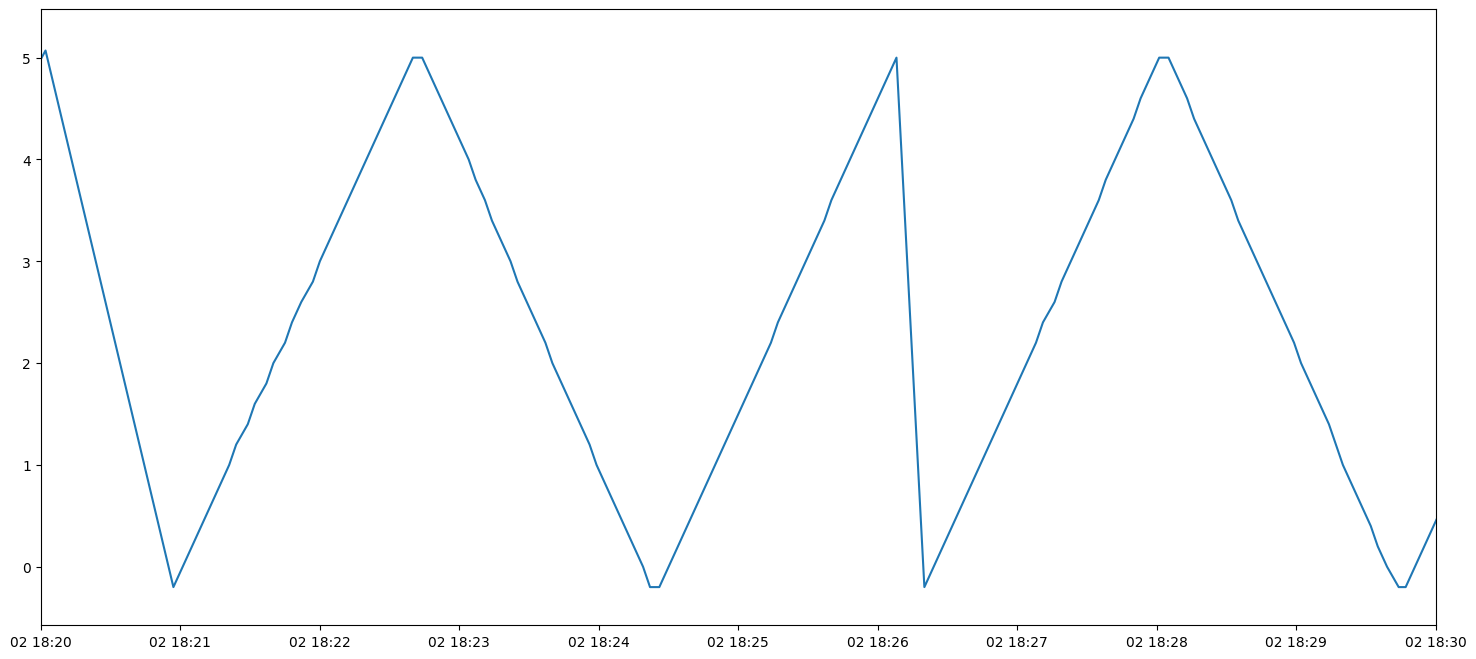

In [27]:
plt.figure(figsize=(18,8))
plt.plot(test_meta['start'], test_meta['zenith'])
t1 = pd.to_datetime('2018-11-02 18:20')
t2 = pd.to_datetime('2018-11-02 18:30')
plt.xlim(t1, t2)
plt.show()

In [28]:
t1a = pd.to_datetime('2018-11-02 18:20:30')
t2a = pd.to_datetime('2018-11-02 18:22:30')
single_scan = test_meta[(test_meta['start']>t1a) & (test_meta['start']<t2a)]

In [29]:
test_files = single_scan['file'].to_list()
scan_df = pd.DataFrame()
for file in test_files:
    df = file_to_data(file)
    scan_df = pd.concat([scan_df, df], ignore_index=True)
scan_df


,analog,photon,start,end,zenith,analog_bgc,photon_bgc,distance,x,z,analog_rcs,photon_rcs
0,3.9551,96.0,2018-11-02 18:20:57,2018-11-02 18:20:57,-0.2,0.0,95.878788,7.5,7.499954,1.973820,0.0,5393.181818
1,4.0039,160.0,2018-11-02 18:20:57,2018-11-02 18:20:57,-0.2,0.0,159.878788,15.0,14.999909,1.947640,0.0,35972.727273
2,3.9551,100.0,2018-11-02 18:20:57,2018-11-02 18:20:57,-0.2,0.0,99.878788,22.5,22.499863,1.921460,0.0,50563.636364
3,3.9307,96.0,2018-11-02 18:20:57,2018-11-02 18:20:57,-0.2,0.0,95.878788,30.0,29.999817,1.895280,0.0,86290.909091
4,3.8574,148.0,2018-11-02 18:20:57,2018-11-02 18:20:57,-0.2,0.0,147.878788,37.5,37.499772,1.869101,0.0,207954.545455
...,...,...,...,...,...,...,...,...,...,...,...,...
1603,3.2959,0.0,2018-11-02 18:22:28,2018-11-02 18:22:28,4.4,0.0,0.000000,472.5,471.107425,38.249741,0.0,0.000000
1604,3.2145,0.0,2018-11-02 18:22:28,2018-11-02 18:22:28,4.4,0.0,0.000000,480.0,478.585321,38.825134,0.0,0.000000
1605,3.2552,0.0,2018-11-02 18:22:28,2018-11-02 18:22:28,4.4,0.0,0.000000,487.5,486.063217,39.400526,0.0,0.000000
1606,3.2756,0.0,2018-11-02 18:22:28,2018-11-02 18:22:28,4.4,0.0,0.000000,495.0,493.541112,39.975919,0.0,0.000000


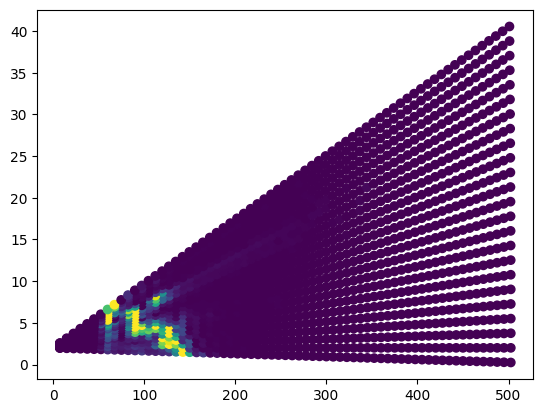

In [30]:
plt.scatter(scan_df['x'], scan_df['z'], c=scan_df['analog_rcs'])

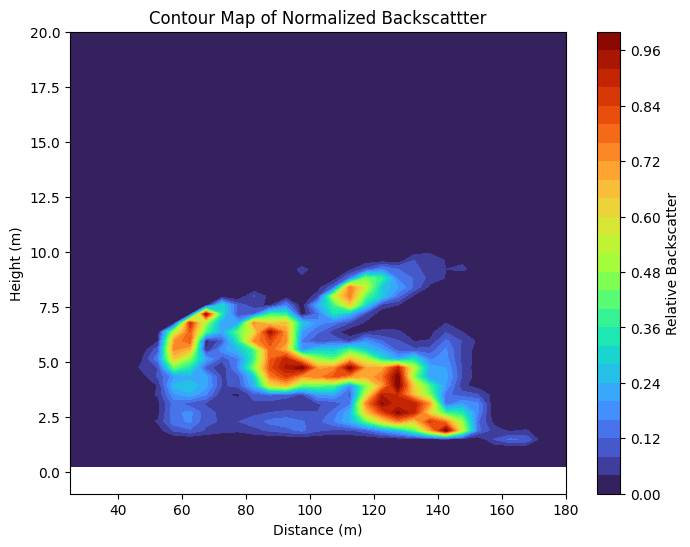

In [31]:
# Extract x, z, and analog_norm
x = scan_df["x"]
z = scan_df["z"]
analog_norm = scan_df["analog_rcs"]

# Create a grid
xi = np.linspace(x.min(), x.max(), 100)
zi = np.linspace(z.min(), z.max(), 100)
Xi, Zi = np.meshgrid(xi, zi)

# Interpolate data
Ai = griddata((x, z), analog_norm, (Xi, Zi), method="linear", fill_value=0) # methods: linear, nearest, cubic

# Plot contour map
plt.figure(figsize=(8, 6))
contour = plt.contourf(Xi, Zi, Ai, cmap="turbo", levels=30) # gist_ncar
plt.colorbar(label="Relative Backscatter")
plt.xlabel("Distance (m)")
plt.ylabel("Height (m)")
plt.title("Contour Map of Normalized Backscattter")
plt.xlim(25,180)
plt.ylim(-1,20)
plt.show()

In [69]:
def plot_contour_scan(scan_df, title=None, x_limits=None, y_limits=None, method='linear', surface=None, mark_max=False):
    x = scan_df["x"]
    z = scan_df["z"]
    analog_norm = scan_df["analog_rcs"]
    
    # Create a grid
    xi = np.linspace(x.min(), x.max(), 100)
    zi = np.linspace(z.min(), z.max(), 100)
    Xi, Zi = np.meshgrid(xi, zi)
    
    # Interpolate data
    Ai = griddata((x, z), analog_norm, (Xi, Zi), method=method) # methods: linear, nearest, cubic
    
    # Plot contour map
    plt.figure(figsize=(15, 6))
    contour = plt.contourf(Xi, Zi, Ai, cmap="turbo", levels=30) # gist_ncar
    plt.colorbar(label="Relative Backscatter")
    plt.xlabel("Distance (m)")
    plt.ylabel("Height (m)")
    if title == None:
        plt.title("Contour Map of Normalized Backscattter")
    else:
        plt.title(title)
    if surface:
        plt.plot(surface['x'], surface['z'])
    if x_limits:
        plt.xlim(x_limits[0], x_limits[1])
    if y_limits:
        plt.ylim(y_limits[0], y_limits[1])


    if mark_max==True:
        # find point of max
        max_rcs_index = scan_df['analog_rcs'].idxmax()
        max_backscatter_data = scan_df.loc[max_rcs_index]
        
        max_x = max_backscatter_data['x']
        max_z = max_backscatter_data['z']
                
        plt.annotate(
            'Maximum Backscatter', 
            xy=(max_x, max_z),  
            xytext=(100,25),       
            arrowprops=dict(
                arrowstyle='->',  
                color='red',      
                lw=2             
            ),
            fontsize=12,          
            color='green'          
        )
    
    plt.show()
    

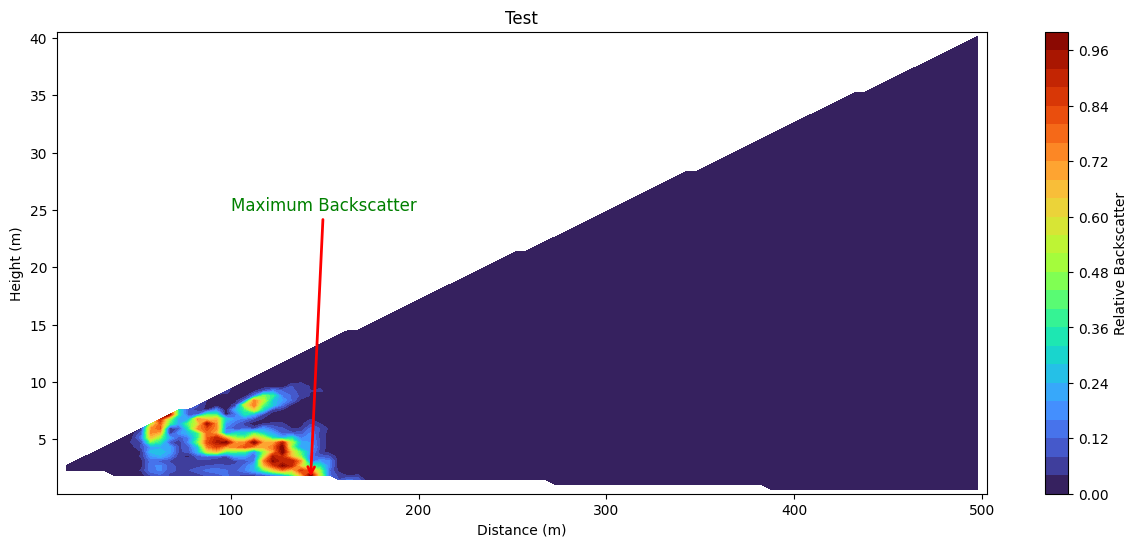

In [70]:
plot_contour_scan(scan_df=scan_df, title='Test', mark_max=True)

In [71]:
import bens_functions as functions

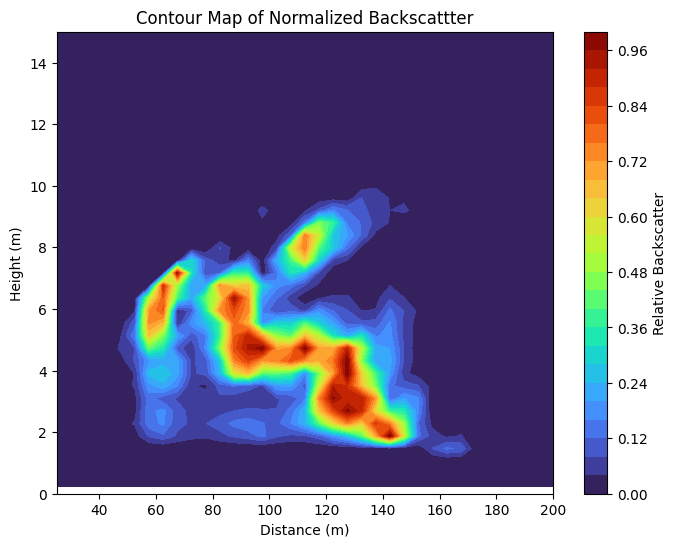

In [72]:
functions.plot_contour_scan(scan_df=scan_df, x_limits=(25,200), y_limits=(0,15))

In [36]:
lidar_data_dir = './data/raw_lidar/extracted_data'
iops = ([name for name in os.listdir(lidar_data_dir) if name.endswith('2018')])
iops.sort()
print(iops)

['10272018', '11022018', '11072018', '11102018', '11112018', '11132018']


In [37]:
iop_1027 = read_metadata(os.path.join(lidar_data_dir, iops[0]))
iop_1102 = read_metadata(os.path.join(lidar_data_dir, iops[1]))
iop_1107 = read_metadata(os.path.join(lidar_data_dir, iops[2]))
iop_1110 = read_metadata(os.path.join(lidar_data_dir, iops[3]))
iop_1111 = read_metadata(os.path.join(lidar_data_dir, iops[4]))
iop_1113 = read_metadata(os.path.join(lidar_data_dir, iops[5]))

/tmp/ipykernel_1152263/4112746237.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  meta_df = pd.concat([meta_df, temp_meta_df], ignore_index=True)
/tmp/ipykernel_1152263/4112746237.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  meta_df = pd.concat([meta_df, temp_meta_df], ignore_index=True)
/tmp/ipykernel_1152263/4112746237.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or 

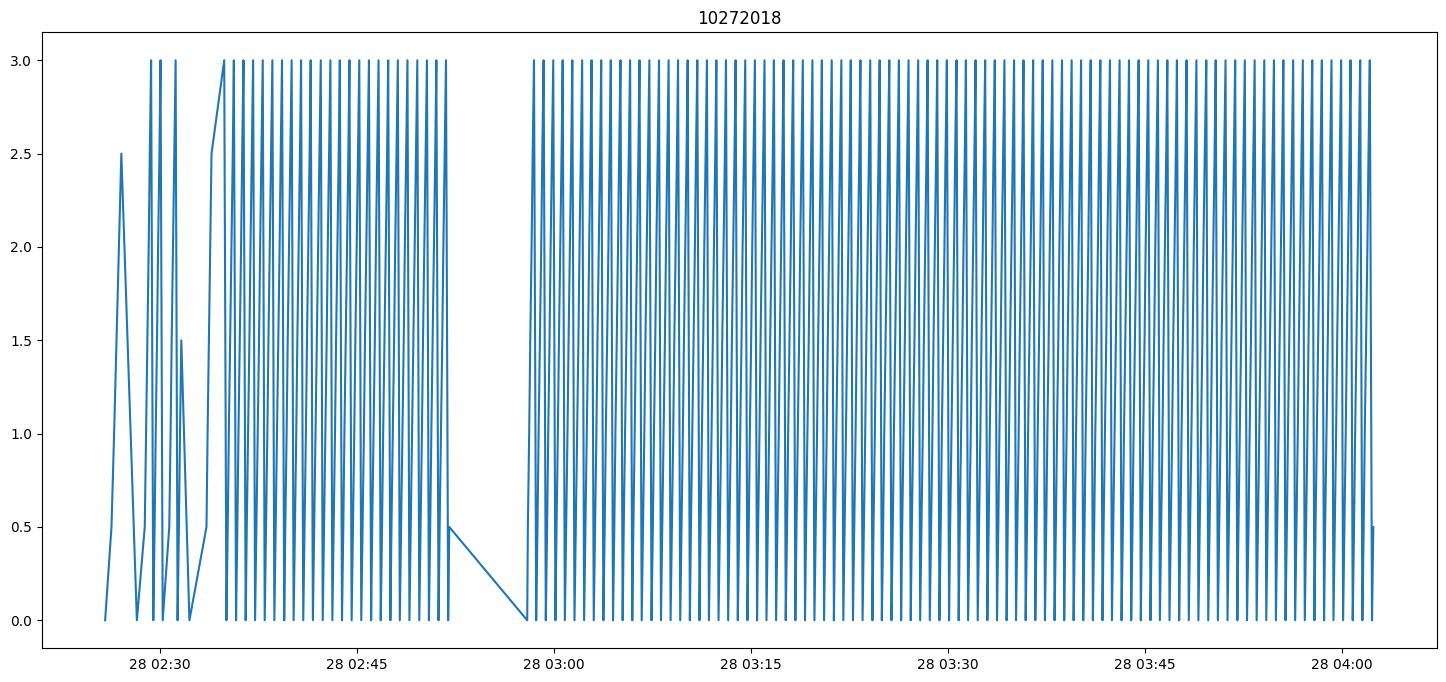

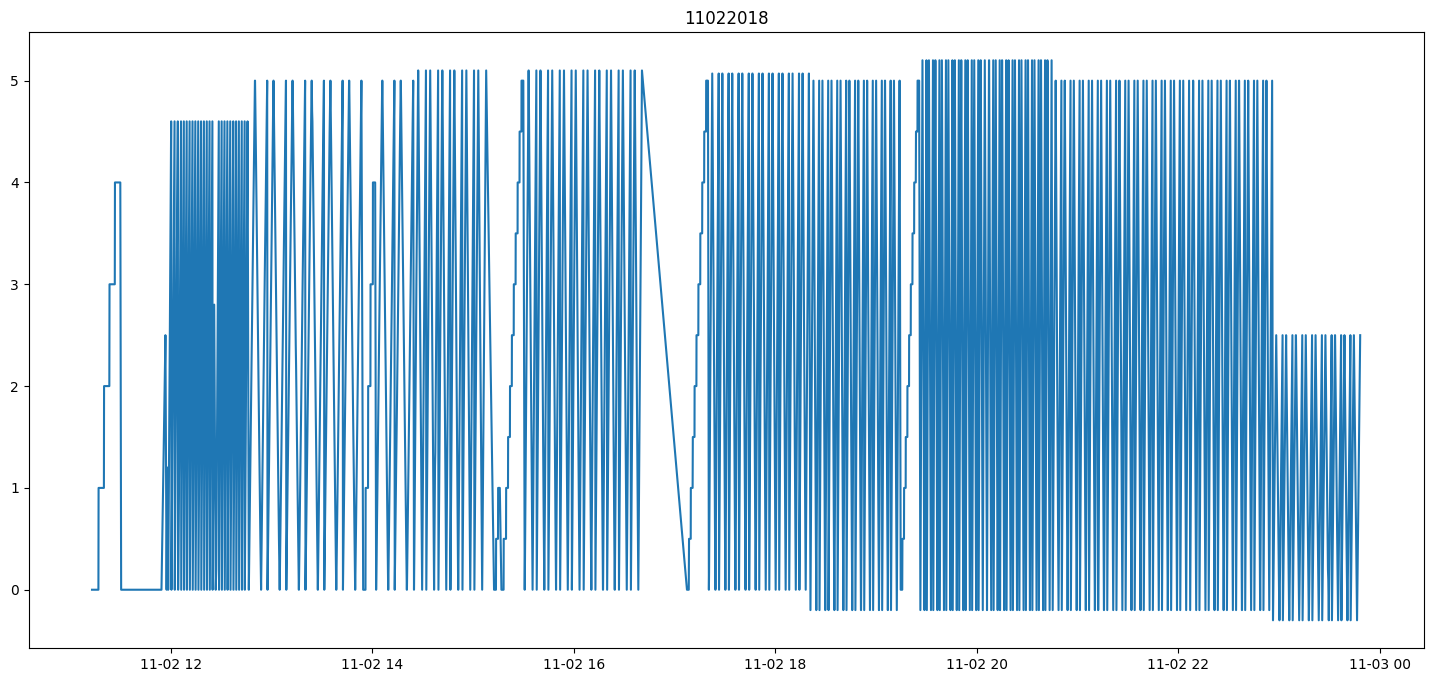

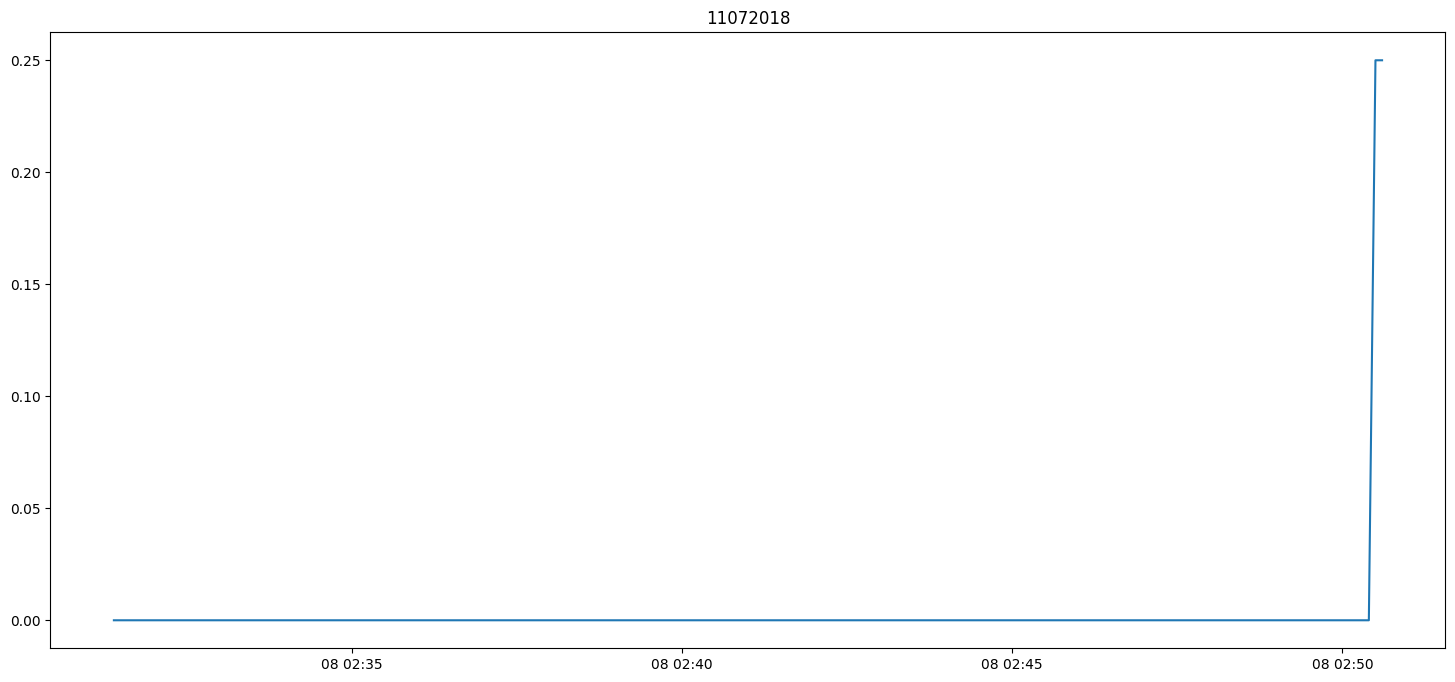

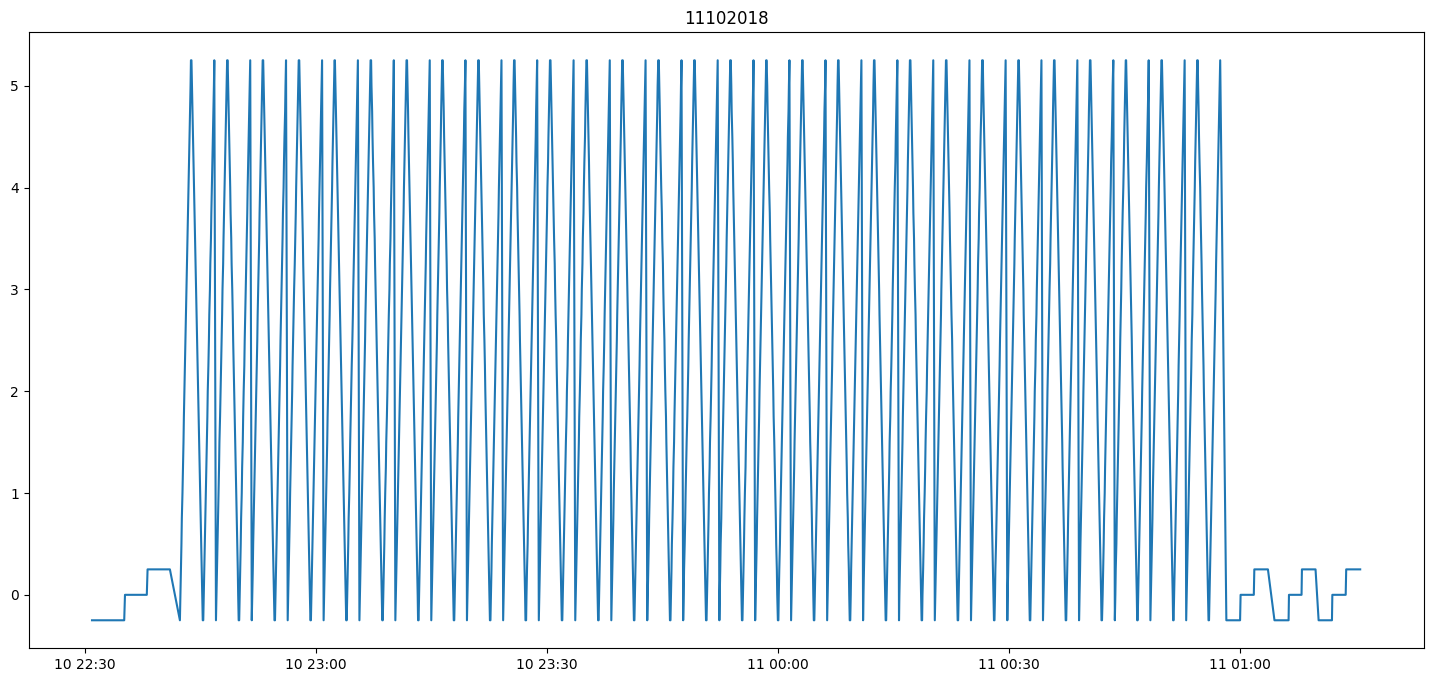

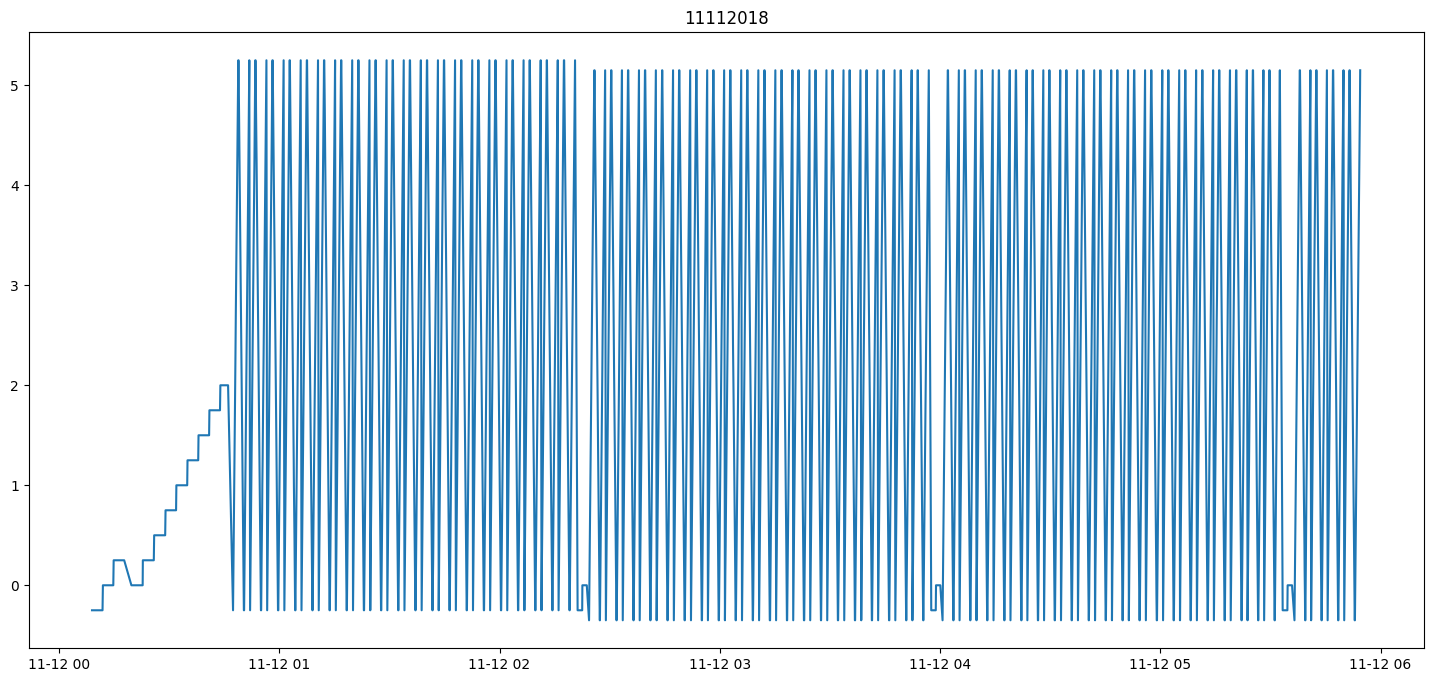

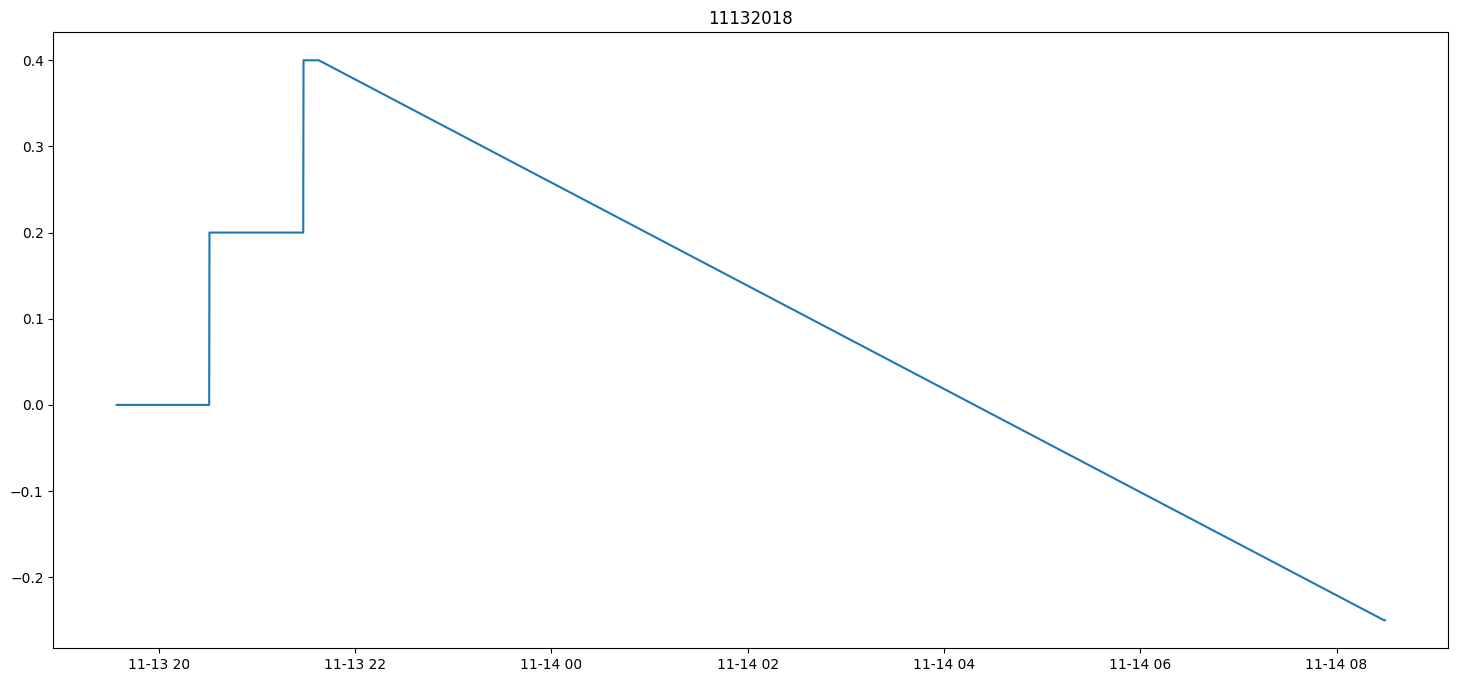

In [38]:
iop_meta_dfs = [iop_1027, iop_1102, iop_1107, iop_1110, iop_1111, iop_1113]
for i, df in enumerate(iop_meta_dfs):
    plt.figure(figsize=(18,8))
    plt.plot(df['start'], df['zenith'])
    plt.title(iops[i])
    # t1 = pd.to_datetime('2018-11-02 18:20')
    # t2 = pd.to_datetime('2018-11-02 18:30')
    # plt.xlim(t1, t2)
    plt.show()

In [39]:
# find local min max indices
max_zenith_idxes = argrelextrema(iop_1027['zenith'].values, np.greater)[0]
min_zenith_idxes = argrelextrema(iop_1027['zenith'].values, np.less)[0]

# Merge and sort extrema indices
min_max = np.sort(np.concatenate((max_zenith_idxes, min_zenith_idxes)))
min_max = np.insert(min_max, 0, 0)   # insert 0 so we can start with the initial row.
if len(iop_1027['zenith'])-1 not in min_max:   # add last row to the end.
    min_max = np.insert(min_max, len(min_max), len(iop_1027['zenith'])-1)

min_max

array([  0,   5,   6,  12,  13,  19,  20,  26,  27,  30,  31,  37,  38,
        44,  45,  51,  52,  58,  59,  65,  66,  72,  73,  79,  80,  86,
        87,  93,  94, 100, 101, 107, 108, 114, 115, 121, 122, 128, 129,
       135, 136, 142, 143, 149, 150, 156, 157, 163, 164, 170, 171, 177,
       178, 184, 185, 191, 192, 198, 199, 200, 201, 207, 208, 214, 215,
       221, 222, 228, 229, 235, 236, 242, 243, 249, 250, 256, 257, 263,
       264, 270, 271, 277, 278, 284, 285, 291, 292, 298, 299, 305, 306,
       312, 313, 319, 320, 326, 327, 333, 334, 340, 341, 347, 348, 354,
       355, 361, 362, 368, 369, 375, 376, 382, 383, 389, 390, 396, 397,
       403, 404, 410, 411, 417, 418, 424, 425, 431, 432, 438, 439, 445,
       446, 452, 453, 459, 460, 466, 467, 473, 474, 480, 481, 487, 488,
       494, 495, 501, 502, 508, 509, 515, 516, 522, 523, 529, 530, 536,
       537, 543, 544, 550, 551, 557, 558, 564, 565, 571, 572, 578, 579,
       585, 586, 592, 593, 599, 600, 606, 607, 613, 614, 620, 62

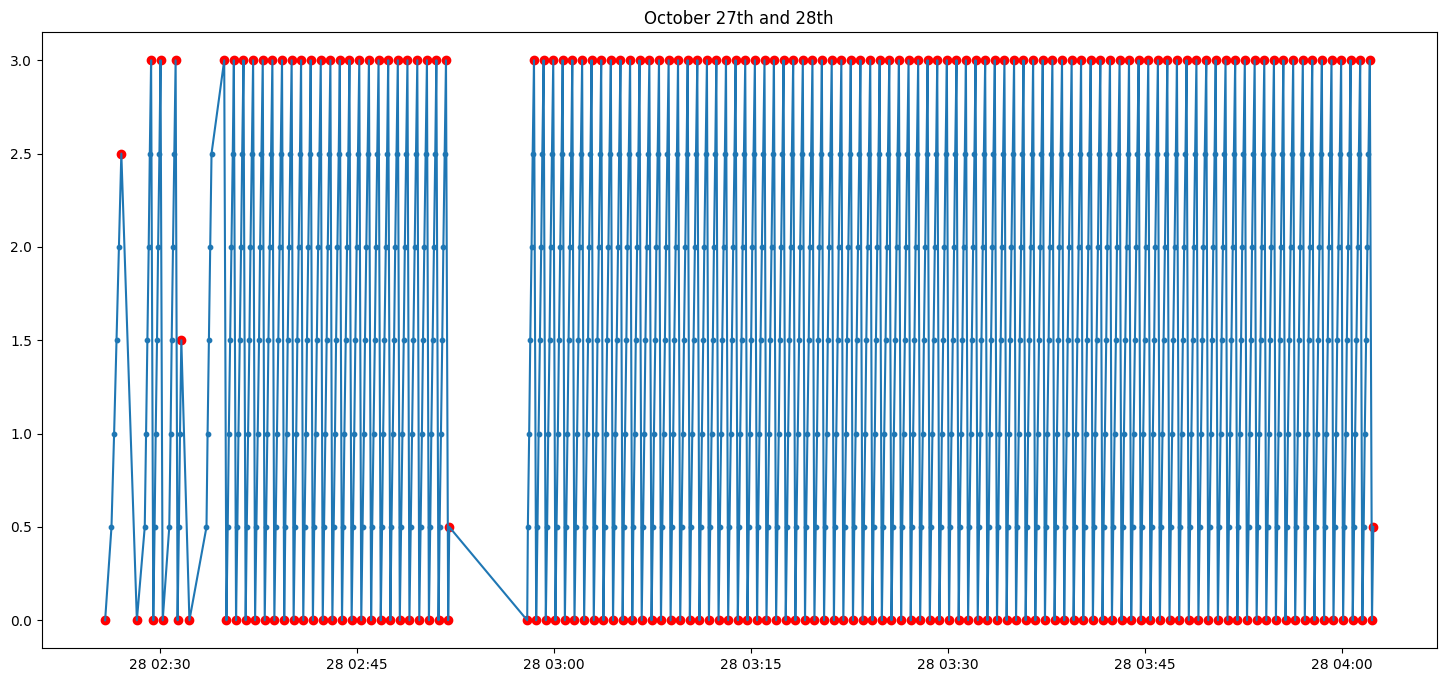

In [40]:
times = []
zeniths = []
for extrema in min_max:
    row = iop_1027.iloc[extrema]
    times.append(row['start'])
    zeniths.append(row['zenith'])

plt.figure(figsize=(18,8))
plt.plot(iop_1027['start'], iop_1027['zenith'])
plt.scatter(iop_1027['start'], iop_1027['zenith'], s=10)
plt.title('October 27th and 28th')

plt.scatter(times, zeniths, color='red')
# t1 = pd.to_datetime('2018-10-28 03:00')
# t2 = pd.to_datetime('2018-10-28 03:15')
# plt.xlim(t1, t2)
plt.show()

In [41]:
start_stop_pairs = []
for i in range(len(min_max)-1):
    if min_max[i+1] - min_max[i] > 4:
        start_stop_pairs.append([int(min_max[i]), int(min_max[i+1])])
    # else:
    #     print(f'not added {min_max[i+1]} - {min_max[i]} = {min_max[i+1] - min_max[i]}')
# for row in start_stop_pairs:
#     print(row)

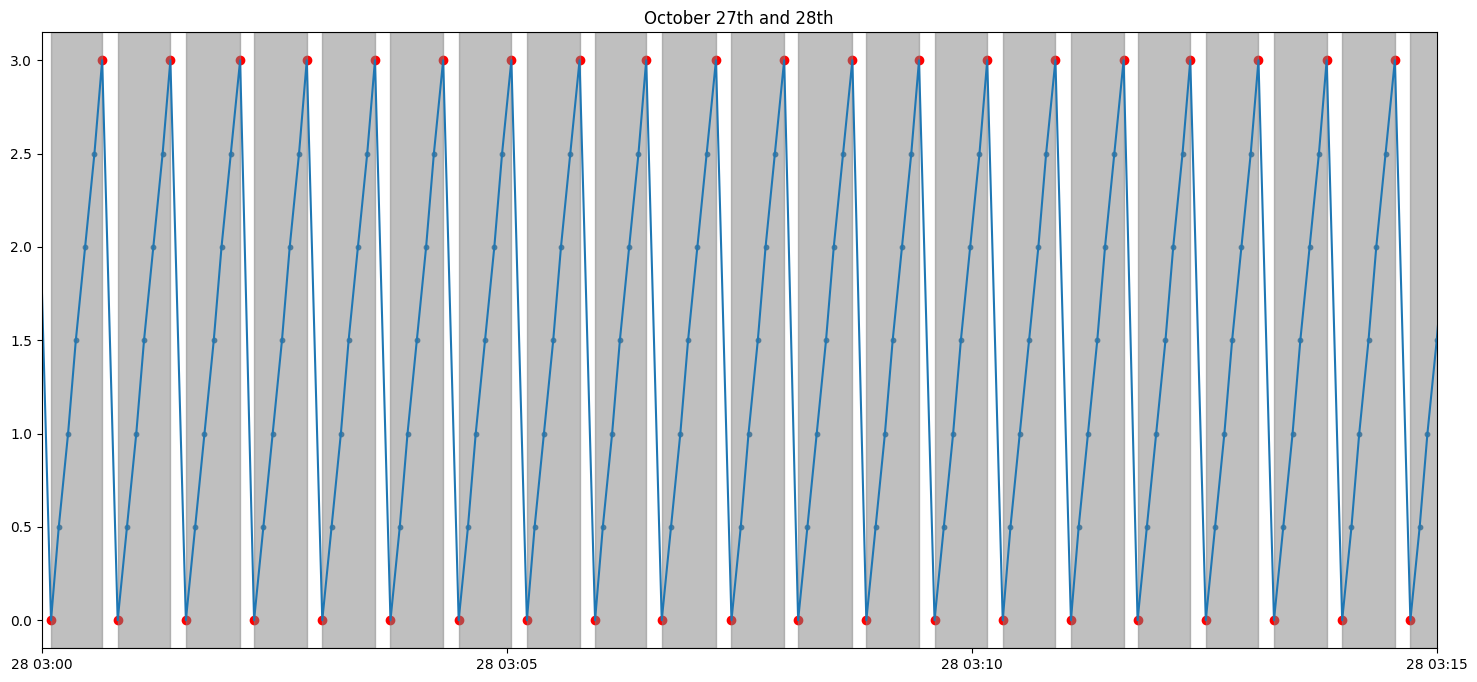

In [42]:
plt.figure(figsize=(18,8))
plt.plot(iop_1027['start'], iop_1027['zenith'])
plt.scatter(iop_1027['start'], iop_1027['zenith'], s=10)
plt.title('October 27th and 28th')

plt.scatter(times, zeniths, color='red')
t1 = pd.to_datetime('2018-10-28 03:00')
t2 = pd.to_datetime('2018-10-28 03:15')
plt.xlim(t1, t2)
for row in start_stop_pairs:
    plt.axvspan(iop_1027.iloc[row[0]]['start'], iop_1027.iloc[row[1]]['start'], color='grey', alpha=0.5)
plt.show()

In [43]:
def find_scans(df, start_time=None, end_time=None):
    # find local min max indices
    max_zenith_idxes= find_peaks(df['zenith'].values)[0] #argrelextrema(df['zenith'].values, np.greater)[0]  
    min_zenith_idxes = find_peaks(-df['zenith'].values)[0] # argrelextrema(df['zenith'].values, np.less)[0]

    # Merge and sort extrema indices
    min_max = np.sort(np.concatenate((max_zenith_idxes, min_zenith_idxes)))
    min_max = np.insert(min_max, 0, 0)   # insert 0 so we can start with the initial row.
    if len(df['zenith'])-1 not in min_max:   # add last row to the end.
        min_max = np.insert(min_max, len(min_max), len(df['zenith'])-1)

    # organize lists of indexes
    times = []
    zeniths = []
    for extrema in min_max:
        row = df.iloc[extrema]
        times.append(row['start'])
        zeniths.append(row['zenith'])

    start_stop_pairs = []
    for i in range(len(min_max)-1):
        if min_max[i+1] - min_max[i] > 4:
            start_stop_pairs.append([int(min_max[i]), int(min_max[i+1])])

    time_stamp_pairs = []
    for pair in start_stop_pairs:
        time_stamp_pairs.append([df.iloc[pair[0]]['start'], df.iloc[pair[1]]['start']])
        
    
    # Plot a figure to test. 
    plt.figure(figsize=(18,8))
    plt.plot(df['start'], df['zenith'])
    plt.title(f"{df.iloc[0]['start']}-{df.iloc[-1]['start']}")
    
    plt.scatter(df['start'], df['zenith'], s=10)  
    plt.scatter(times, zeniths, color='red')
    
    if start_time != None and end_time != None:
        t1 = pd.to_datetime(start_time)
        t2 = pd.to_datetime(end_time)
        plt.xlim(t1, t2)
    for row in start_stop_pairs:
        plt.axvspan(df.iloc[row[0]]['start'], df.iloc[row[1]]['start'], color='grey', alpha=0.25)
    plt.show()
    return start_stop_pairs, time_stamp_pairs


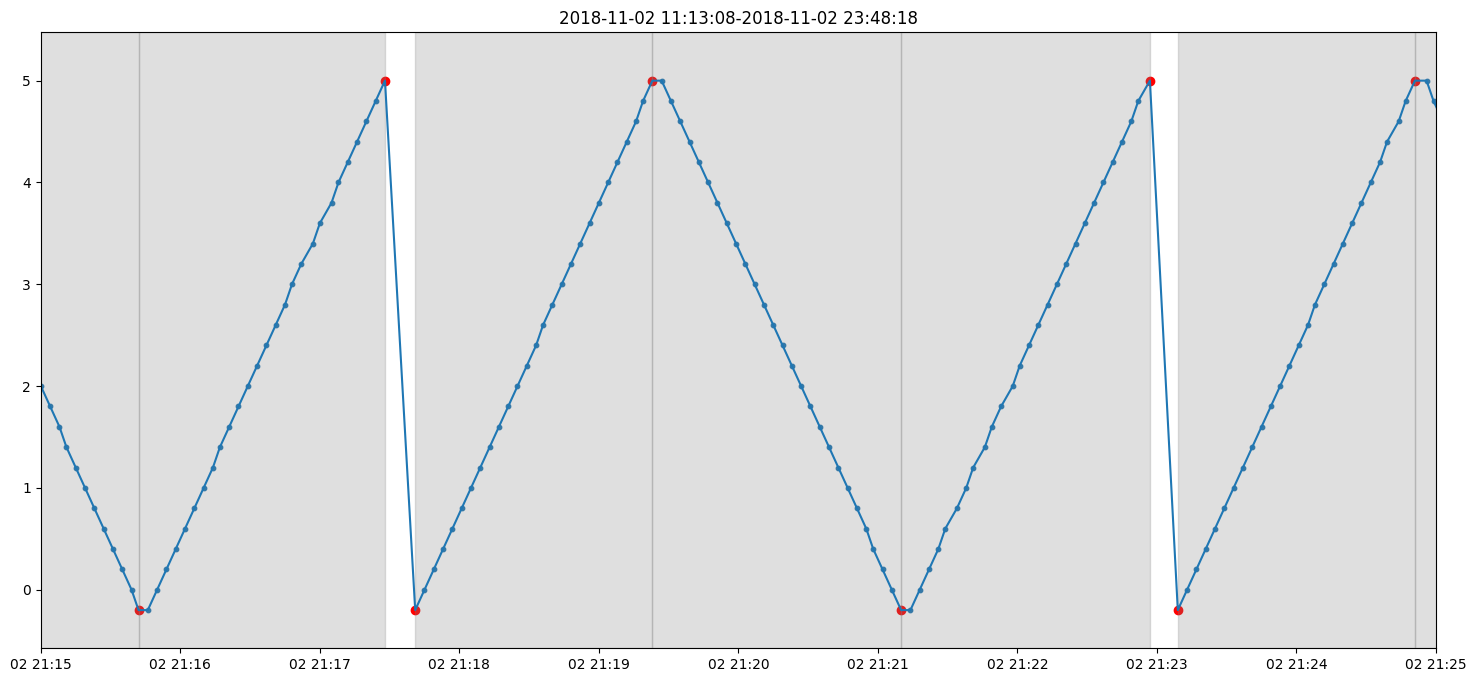

In [44]:
iop_1102_ind, iop_1102_times = find_scans(iop_1102, '2018-11-02 21:15', '2018-11-02 21:25') #Timestamp('2018-11-02 18:59:59'), Timestamp('2018-11-02 19:01:42')

In [45]:
iop_1102_df = pd.DataFrame()
for file in os.listdir('./data/raw_lidar/extracted_data/11022018'):
    if file.endswith('.txt'):
        temp_df = file_to_data(os.path.join('./data/raw_lidar/extracted_data/11022018', file))
        iop_1102_df = pd.concat((iop_1102_df, temp_df), ignore_index=True)



In [46]:
def process_iop(directory):
    df = pd.DataFrame()
    for file in os.listdir(directory):
        if file.endswith('.txt'):
            temp_df = file_to_data(os.path.join(directory, file))
            df = pd.concat((df, temp_df), ignore_index=True)
    return df

In [47]:
test_iop = process_iop('./data/raw_lidar/extracted_data/11022018')
test_iop.describe()

,analog,photon,start,end,zenith,analog_bgc,photon_bgc,distance,x,z,analog_rcs,photon_rcs
count,670335.000000,670335.000000,670335,670335,670335.000000,670335.000000,670335.000000,670335.000000,670335.000000,670335.000000,670335.000000,6.703350e+05
mean,22.889999,111.692756,2018-11-02 17:55:35.273862912,2018-11-02 17:55:35.400499712,2.331864,15.029647,17.967313,255.000000,254.697070,12.371477,0.206515,5.065001e+05
min,0.000000,0.000000,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.300000,0.000000,0.000000,7.500000,7.469133,-0.631072,0.000000,0.000000e+00
25%,5.696600,96.000000,2018-11-02 14:48:18,2018-11-02 14:48:18,1.000000,0.000000,0.000000,127.500000,127.480581,4.391446,0.000000,0.000000e+00
50%,9.790000,120.000000,2018-11-02 18:09:34,2018-11-02 18:09:34,2.200000,0.000000,0.000000,255.000000,254.812044,9.397525,0.000000,0.000000e+00
75%,25.538200,136.666700,2018-11-02 21:00:06,2018-11-02 21:00:06,3.600000,15.795145,30.787879,382.500000,381.745224,17.966520,0.382350,8.052136e+05
max,599.853500,268.000000,2018-11-02 23:48:18,2018-11-02 23:48:18,5.200000,595.967233,187.151515,502.500000,502.500000,47.542872,1.000000,9.709555e+06
std,40.469002,38.284648,NaN,NaN,1.537907,40.098164,22.994126,145.043205,144.871312,9.832049,0.313029,8.040942e+05


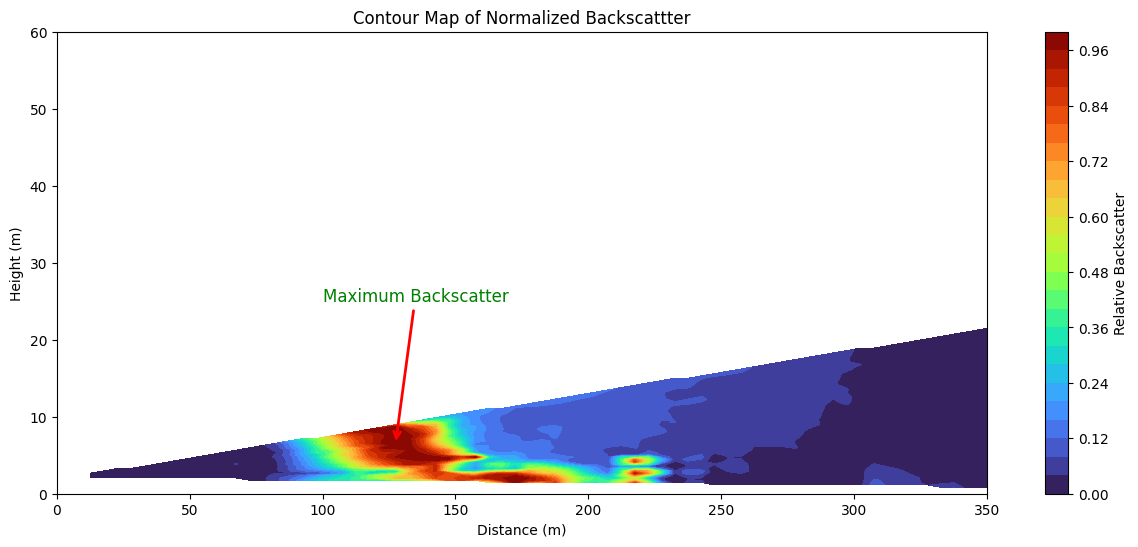

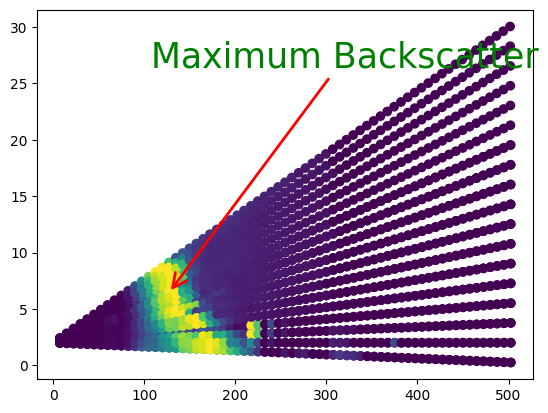

In [74]:
start = pd.to_datetime('2018-11-02 21:20')
stop = pd.to_datetime('2018-11-02 21:22')
temp = iop_1102_df[(iop_1102_df['start']>start) & (iop_1102_df['start']<=stop)]

# find point of max
max_rcs_index = temp['analog_rcs'].idxmax()
max_backscatter_data = temp.loc[max_rcs_index]

max_x = max_backscatter_data['x']
max_z = max_backscatter_data['z']

plot_contour_scan(temp, x_limits=(0, 350), y_limits=(0, 60), method='linear', mark_max=True)

plt.annotate(
    'Maximum Backscatter', 
    xy=(max_x, max_z),  
    xytext=(max_x-20, max_z+20),       
    arrowprops=dict(
        arrowstyle='->',  
        color='red',      
        lw=2             
    ),
    fontsize=25,          
    color='green'          
)


plt.scatter(temp['x'], temp['z'], c=temp['analog_rcs'])

In [58]:
temp[]

,analog,photon,start,end,zenith,analog_bgc,photon_bgc,distance,x,z,analog_rcs,photon_rcs
6365,3.1738,124.0,2018-11-02 21:20:27,2018-11-02 21:20:27,2.0,0.0,33.575758,7.5,7.495431,2.261746,0.0,1888.636364
6366,3.1982,112.0,2018-11-02 21:20:27,2018-11-02 21:20:27,2.0,0.0,0.000000,15.0,14.990862,2.523492,0.0,0.000000
6367,3.1982,136.0,2018-11-02 21:20:27,2018-11-02 21:20:27,2.0,0.0,45.575758,22.5,22.486294,2.785239,0.0,23072.727273
6368,3.1494,156.0,2018-11-02 21:20:27,2018-11-02 21:20:27,2.0,0.0,65.575758,30.0,29.981725,3.046985,0.0,59018.181818
6369,3.1738,144.0,2018-11-02 21:20:27,2018-11-02 21:20:27,2.0,0.0,53.575758,37.5,37.477156,3.308731,0.0,75340.909091
...,...,...,...,...,...,...,...,...,...,...,...,...
644669,3.8086,40.0,2018-11-02 21:21:06,2018-11-02 21:21:06,-0.0,0.0,0.000000,472.5,472.500000,2.000000,0.0,0.000000
644670,3.6133,32.0,2018-11-02 21:21:06,2018-11-02 21:21:06,-0.0,0.0,0.000000,480.0,480.000000,2.000000,0.0,0.000000
644671,3.8086,20.0,2018-11-02 21:21:06,2018-11-02 21:21:06,-0.0,0.0,0.000000,487.5,487.500000,2.000000,0.0,0.000000
644672,3.6377,24.0,2018-11-02 21:21:06,2018-11-02 21:21:06,-0.0,0.0,0.000000,495.0,495.000000,2.000000,0.0,0.000000


In [49]:
iop_1102_df.sort_values(by='start')

,analog,photon,start,end,zenith,analog_bgc,photon_bgc,distance,x,z,analog_rcs,photon_rcs
450842,7.6367,99.5,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,0.000000,0.000000,502.5,502.500000,2.000000,0.000000,0.000000e+00
450810,20.5853,125.5,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,8.664024,0.000000,262.5,262.500000,2.000000,0.563168,0.000000e+00
450811,19.5526,128.5,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,7.631324,11.878788,270.0,270.000000,2.000000,0.524792,8.659636e+05
450812,18.8928,135.0,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,6.971524,18.378788,277.5,277.500000,2.000000,0.506423,1.415282e+06
450813,17.7191,122.5,2018-11-02 11:13:08,2018-11-02 11:13:10,-0.0,5.797824,0.000000,285.0,285.000000,2.000000,0.444237,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...
168728,52.0508,136.0,2018-11-02 23:48:18,2018-11-02 23:48:18,2.5,41.327115,18.787879,172.5,172.335818,9.524344,1.000000,5.590568e+05
168727,51.3672,124.0,2018-11-02 23:48:18,2018-11-02 23:48:18,2.5,40.643515,0.000000,165.0,164.842957,9.197199,0.899800,0.000000e+00
168726,53.8574,140.0,2018-11-02 23:48:18,2018-11-02 23:48:18,2.5,43.133715,22.787879,157.5,157.350095,8.870054,0.870091,5.652818e+05
168732,38.0371,140.0,2018-11-02 23:48:18,2018-11-02 23:48:18,2.5,27.313415,22.787879,202.5,202.307265,10.832926,0.910779,9.344455e+05


In [50]:
len(iop_1102_times[0:10])

10

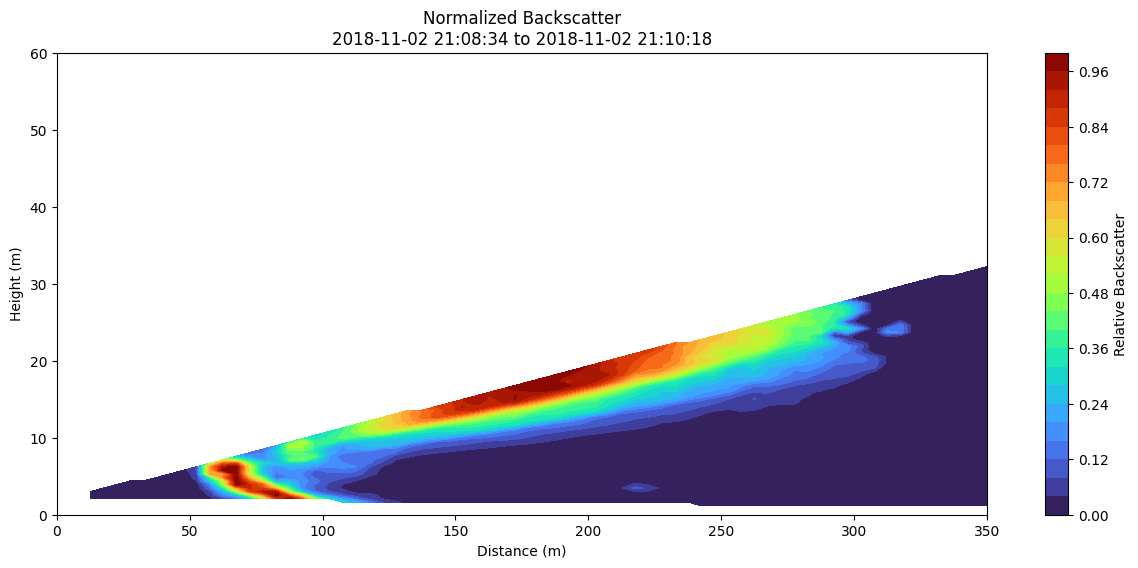

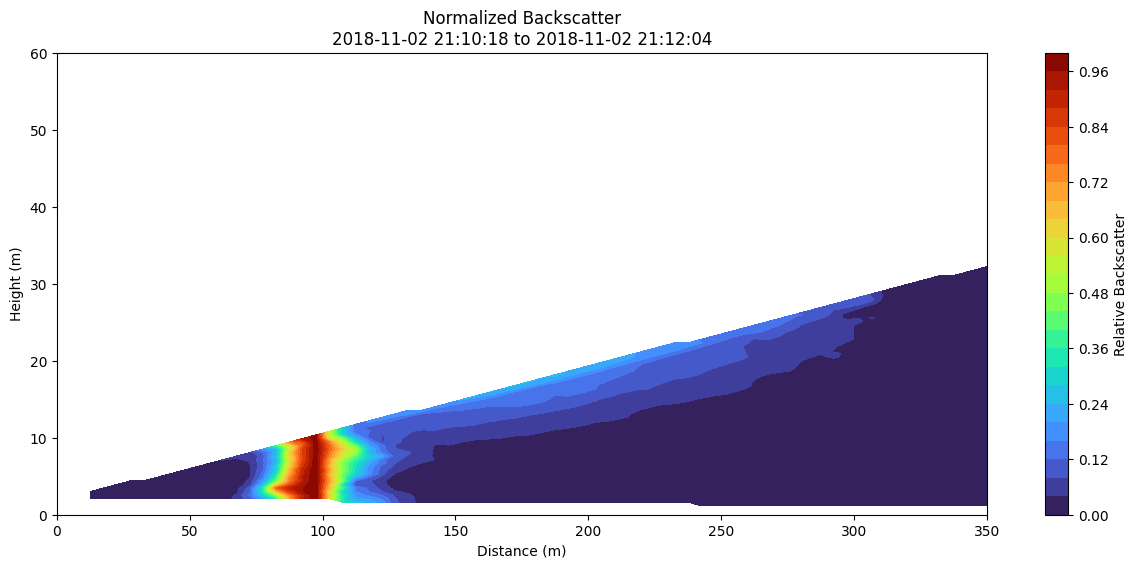

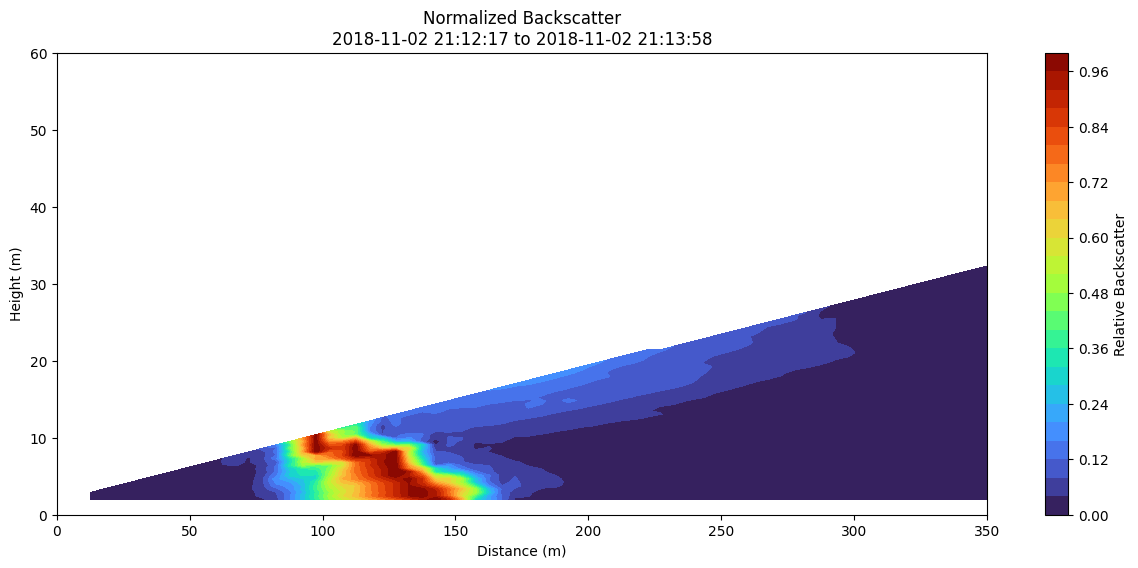

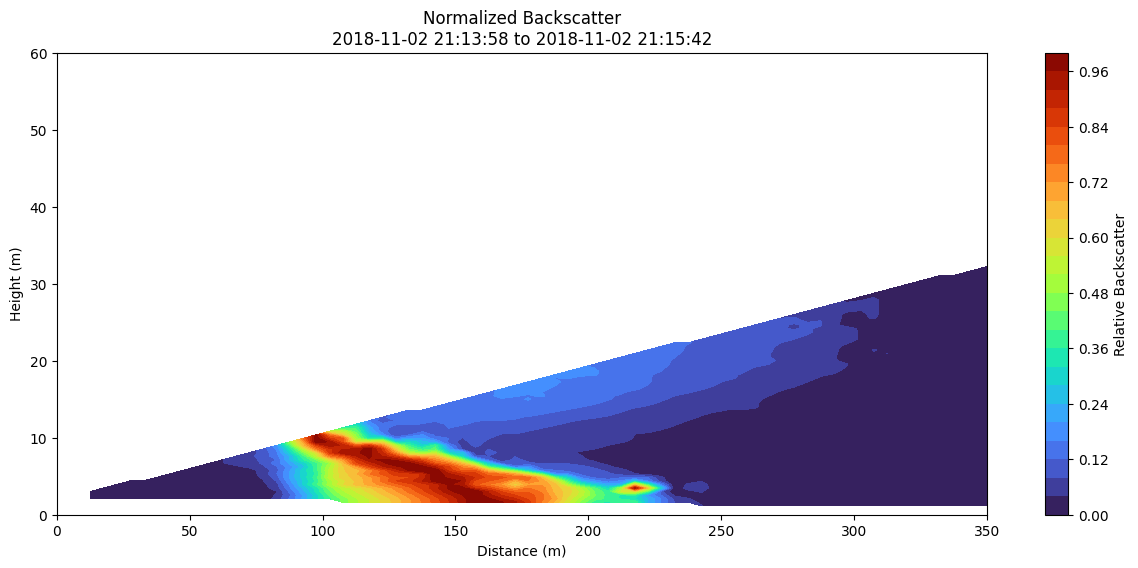

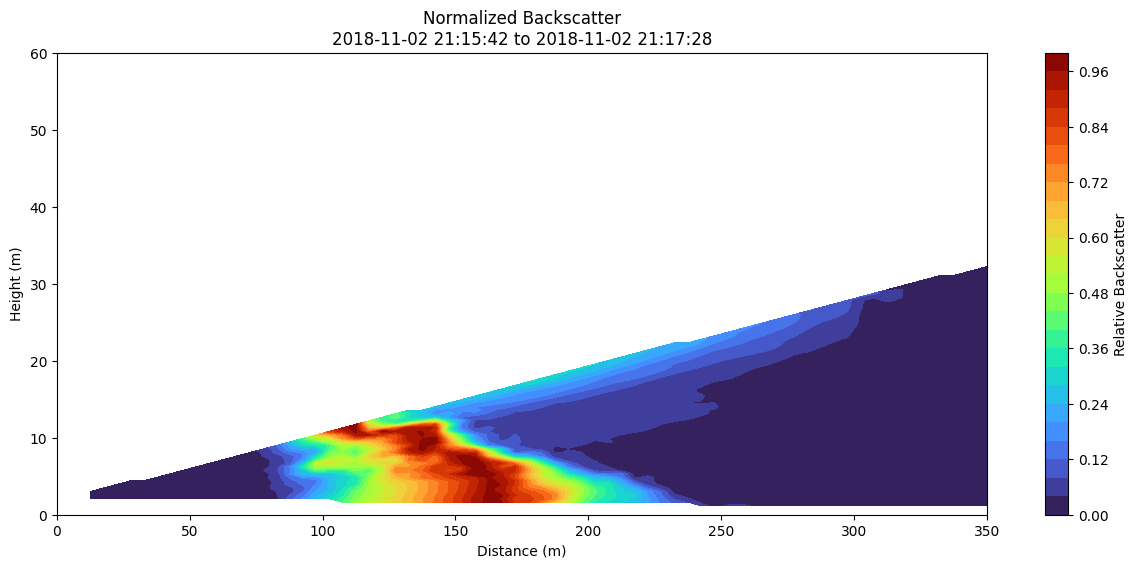

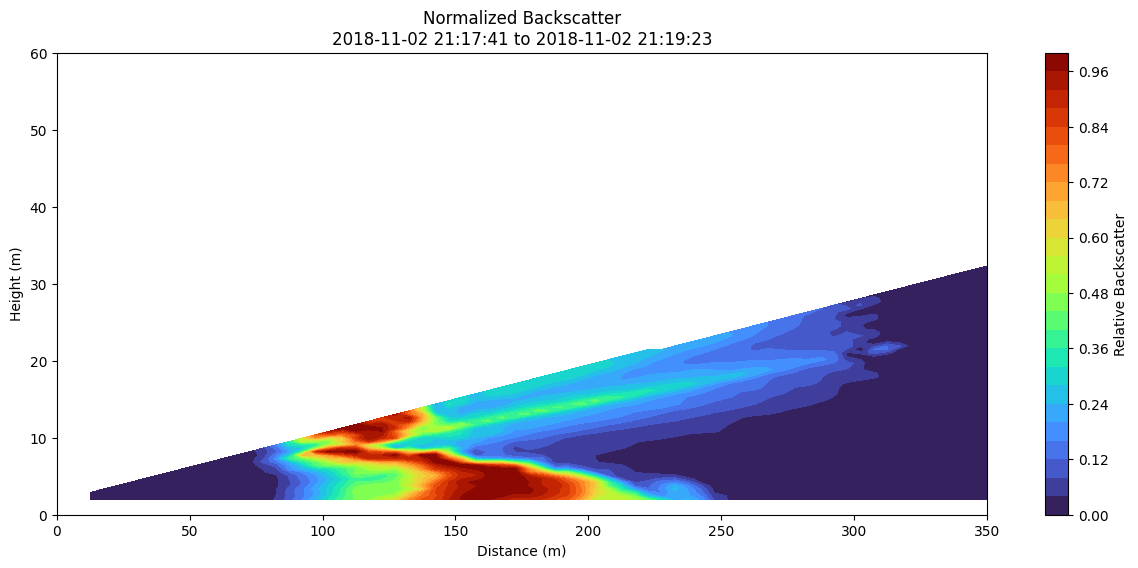

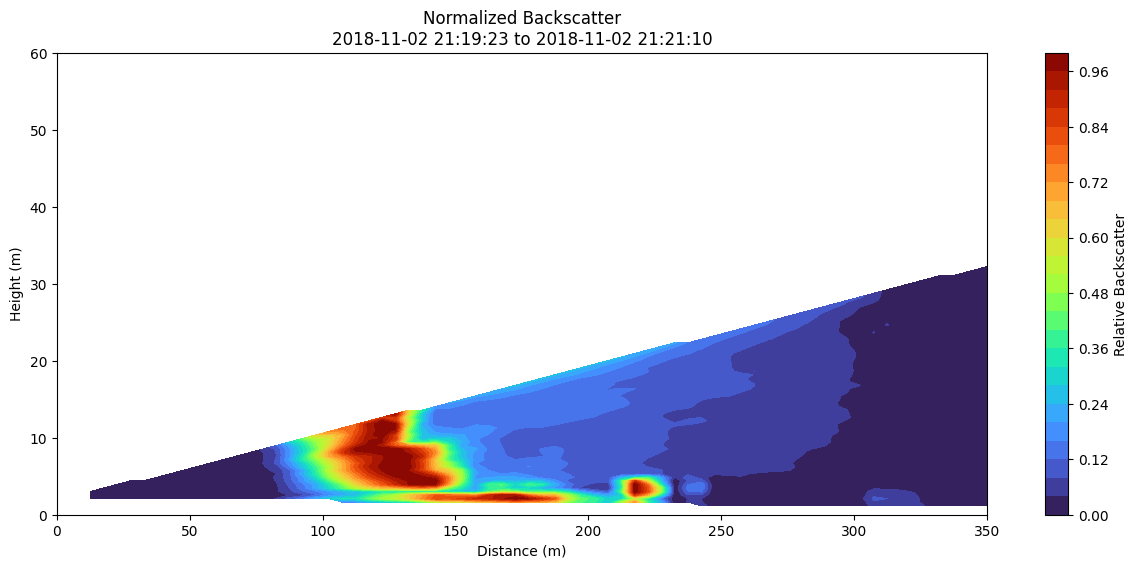

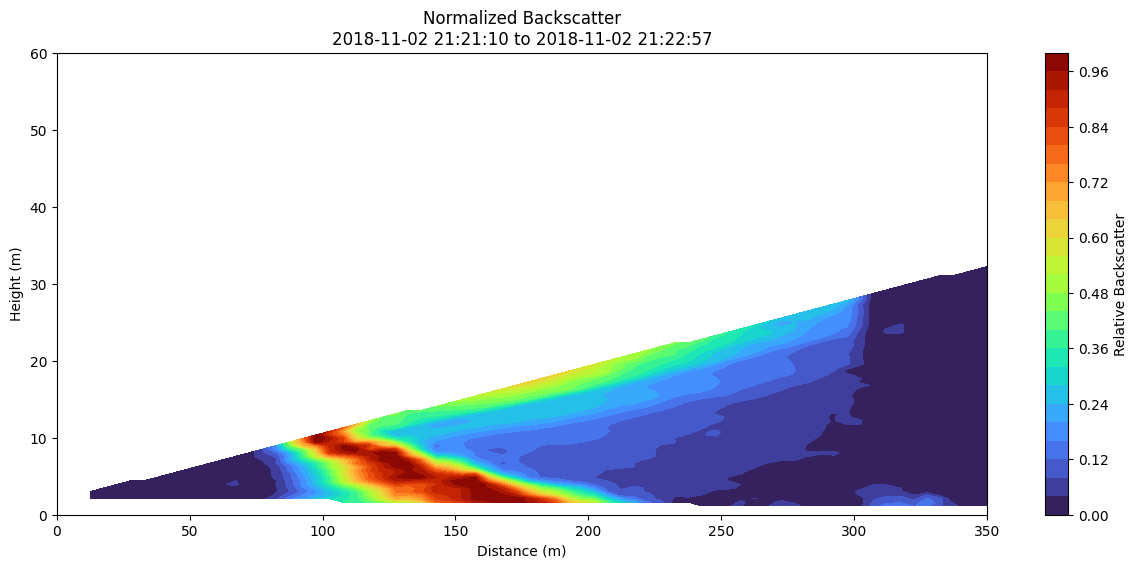

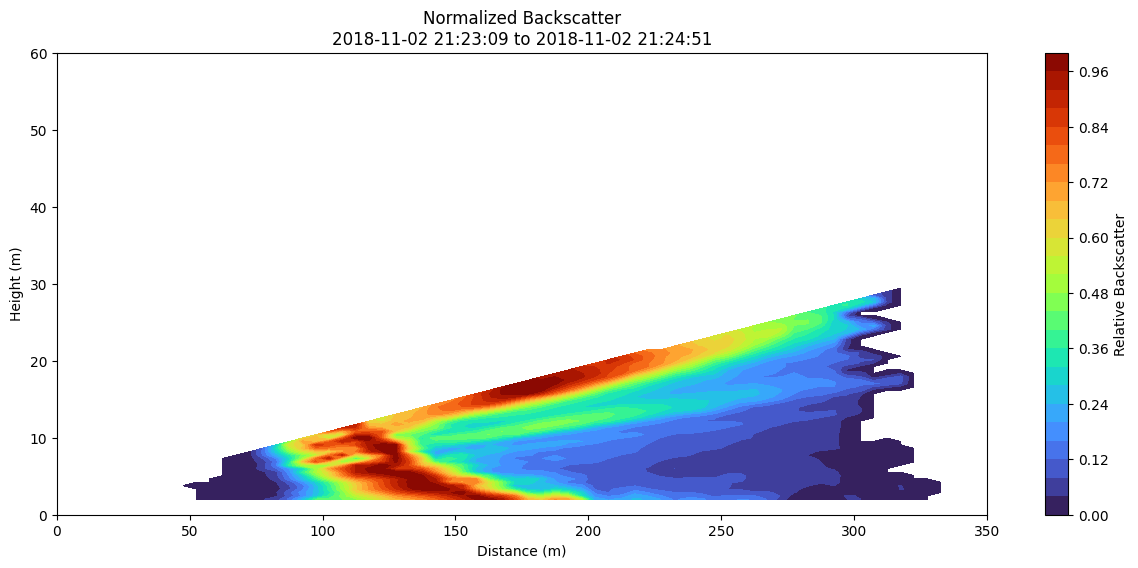

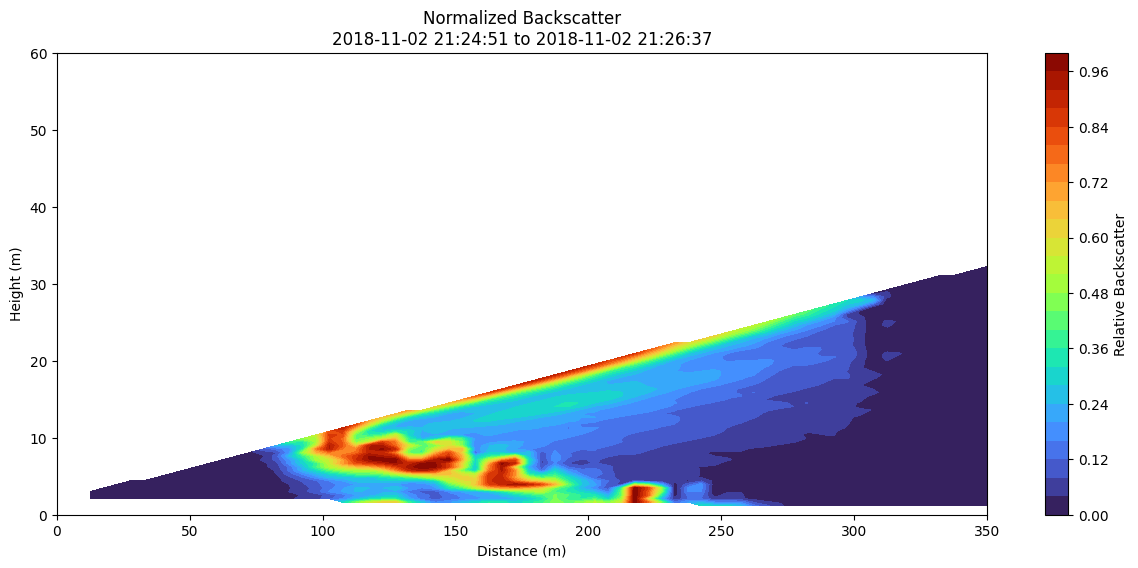

In [51]:
for pair in iop_1102_times[250:260]:
    start = pair[0]
    stop = pair[1]
    temp = iop_1102_df[(iop_1102_df['start']>start) & (iop_1102_df['start']<=stop)]
    plot_contour_scan(temp, x_limits=(0, 350), y_limits=(0, 60), method='linear', title=f'Normalized Backscatter\n{start} to {stop}')
    
    # plt.scatter(temp['x'], temp['z'], c=temp['analog_rcs'])
    

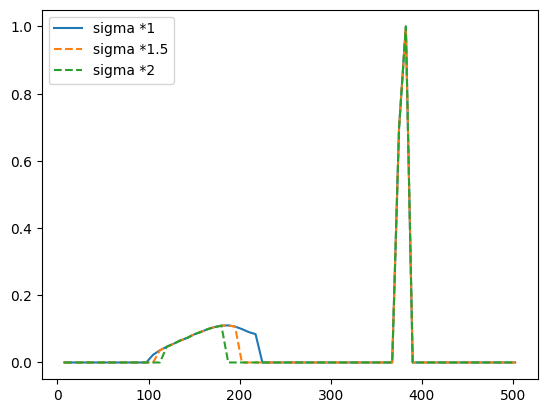

In [56]:
import bens_functions as f
testing1 = f.file_to_data('./data/raw_lidar/extracted_data/11022018/S18B0212.100249.txt')
testing1_5 = f.file_to_data('./data/raw_lidar/extracted_data/11022018/S18B0212.100249.txt', filter_t=1.5)
testing2 = f.file_to_data('./data/raw_lidar/extracted_data/11022018/S18B0212.100249.txt', filter_t=2)
plt.plot(testing1['distance'], testing1['analog_rcs_norm'], label='sigma *1')
plt.plot(testing1_5['distance'], testing1_5['analog_rcs_norm'], label='sigma *1.5', linestyle='--')
plt.plot(testing2['distance'], testing2['analog_rcs_norm'], label='sigma *2', linestyle='--')
plt.legend()
plt.show()

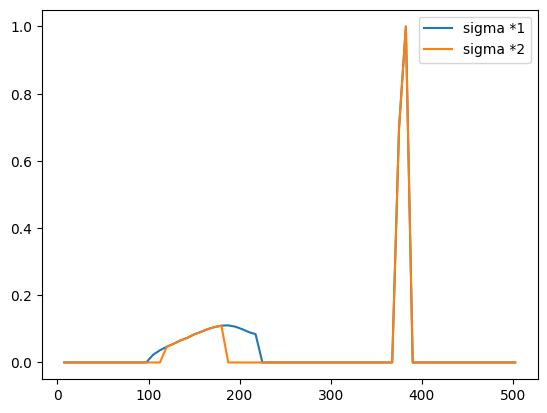

In [54]:
plt.plot(testing1['distance'], testing1['analog_rcs_norm'], label='sigma *1')
plt.plot(testing2['distance'], testing2['analog_rcs_norm'], label='sigma *2')
plt.legend()
plt.show()
